# Libraries

In [118]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import (
    plot_grouped_bar_by_columns,
    plot_single_bar_metric,
    plot_rank_comparison,
    plot_multi_rank_comparison,
    render_dlq_analysis,
)


# Evaluating CLOUDBENCH Benchmarks 

Here we will evaluate the raw query metrics returned by Cloudbench. These raw metrics were calculated using [Cloudbench](https://huggingface.co/datasets/sagecontinuum/Cloudbench) with a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) variation named `DFN5B-CLIP-ViT-H-14-378` trained on a dataset filtered by a [Data Filtering Network (DFN)](https://arxiv.org/abs/2309.17425), [NRP's](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) [gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it), and set to **response_limit=25**. This means it will return up to 25 images. This was configured this way to match production deployment.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.

This version tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` on **Milvus** (replacing Weaviate), using dual dense indexes plus BM25 and CLIP rerank. It included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using NRP's gemma-4-31B-it model.
- **Dual-index Vector Search**: Image and caption CLIP embeddings are stored as separate Milvus fields (`image_vector`, `caption_vector`) instead of a single fused vector. At query time, dense similarity blends both legs with `clip_alpha` (default 0.7 → 70% image / 30% caption).
- **Keyword Search (BM25)**: Milvus BM25 over `search_text` (captions and related text), replacing Weaviate keyword search.
- **Hybrid Search**: Dense (dual CLIP) + sparse (BM25) retrieval via Milvus `WeightedRanker`, controlled by `query_alpha` (default 0.4 → 40% dense / 60% keyword). Query method: `clip_hybrid_query_dual_index`.
- **CLIP Reranker (`DFN5B-CLIP-ViT-H-14-378`)**: Replaces the previous Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. The query text is embedded once and scored against stored `image_vector`s (no per-hit image I/O), matching production `logits_per_image`-style ranking.
- **Triton Dynamic Batching**: CLIP (and Gemma when served on Triton) use server-side dynamic batching so concurrent embedding/caption requests are coalesced into larger GPU batches, improving indexing and query throughput versus one-request-per-inference.
- **LLM Image Byte Limiting**: Caption images are preprocessed with `LLM_IMAGE_BYTE_LIMITING=true` before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB). Cloudbench previously triggered NRP 500 errors when sent at full resolution.

Here were the Hyperparameters used for the image search:

In [119]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,advanced_query_parameters,"{'query_alpha': 0.4, 'clip_alpha': 0.7, 'enabl...",dict
1,caption_model_name,gemma,str
2,caption_model_prompt,\nrole:\nYou are a world-class Scientific Imag...,str
3,cloudbench_dataset,sagecontinuum/CloudBench,str
4,embed_caption,True,bool
5,embed_image,True,bool
6,enable_bm25,True,bool
7,enable_caption_generation,True,bool
8,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
9,hnsw_dynamicEfMax,500,int


## Query and Image Collection Process

This explanation was grabbed from the [dataset card](https://huggingface.co/datasets/sagecontinuum/Cloudbench) in huggingface so that we can better understand the results in further sections.

### Query Collection

Queries in CloudBench are **natural-language descriptions of clouds and atmospheric conditions**, written to reflect how researchers would search for sky and cloud imagery. They are not manually authored by humans; instead they are **generated by an AI text model (OpenAI, GPT-5-mini) from seed images**.

**Process:**

1. **Seed images** — A fixed number of seed images (controlled by the query-plan hyperparameters) are selected from the candidate image pool.
2. **Query generation** — For each seed, the text API is given the image (and any associated context) and is prompted to produce a natural-language query that someone might use to find that kind of cloud or sky scene. The model is instructed to describe cloud types, coverage, and atmospheric conditions so the queries reflect realistic search intents (e.g., "Daytime 'mackerel sky'—numerous small, patchy mid/high‑level cloudlets (altocumulus/cirrocumulus) forming a textured, cellular field with blue sky gaps").
3. **One query per seed** — Each generated query is assigned a unique `query_id` (e.g. `query_002`, `query_003`) and is then used to retrieve and label candidate images.

The result is a set of **expert-style queries** over cloud and atmospheric imagery that support evaluation of text-to-image retrieval, relevance classification, and robustness to confounders (e.g., sun glare, occlusion, lighting). For full pipeline details and hyperparameters, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CloudBench) and the `config_values.csv` in the benchmark's `summary/` directory.


### Image Annotation

CloudBench annotates images in two main ways: **vision-based description** of each image, and **relevance labeling** for each query–image pair. Both are automated with AI models (OpenAI APIs), not human annotators.

**1. Vision annotation (per image)**  
Each image is processed with **OpenAI’s vision API (GPT-5-mini)** to produce:

- **Summary** — A short factual description (≤30 words).
- **Categorical facets** — From fixed taxonomies: `viewpoint` (e.g. ground_upward, ground_horizontal, fisheye_sky), `lighting` (e.g. day, night, dusk, bright, overcast_light), `cloud_coverage` (e.g. 0%-25%, 25%-50%, 50%-75%, 75%-100%), `confounder_type` (e.g. none, fog, sun_glare, precipitation), and boolean facets such as `occlusion_present`, `multiple_cloud_types`, `horizon_visible`, `ground_visible`, `sun_visible`, `precipitation_visible`, `overcast`, `multiple_layers`, `storm_visible`.
- **Controlled vocabulary tags** — Typically 12–18 tags per image (e.g. cirrocumulus_clouds, scattered_clouds, blue_sky, patchy_clouds, sky_dominates).
- **Confidence scores** — For each categorical facet, a score between 0 and 1.

**2. Relevance labeling (per query–image pair)**  
For each query, candidate images are scored as **relevant (1)** or **not relevant (0)** by an **AI judge** using OpenAI’s text API (GPT-5-mini), prompted to reflect whether the image matches the cloud/atmospheric description in the query. This yields the binary `relevance_label` used for retrieval metrics.

**3. CLIPScore (per query–image pair)**  
A **CLIP similarity score** between the query text and the image is computed offline using the model `apple/DFN5B-CLIP-ViT-H-14-378` and stored in the dataset as `clip_score`.

For annotation prompts and hyperparameters (e.g. `VISION_ANNOTATION_*`, `JUDGE_*`), see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CloudBench) and the benchmark’s `summary/config_values.csv`.


### Query Categories

CloudBench does not assign each query to a single category. Instead, **queries are characterized by the same metadata dimensions used for images**, so that retrieval can be analyzed (and evaluated) along cloud- and atmospheric-science-relevant axes. Each query–image pair has metadata from these **locked taxonomies** (defined in the dataset creation config):

- **viewpoint** — How the scene was captured (e.g. `ground_upward`, `ground_horizontal`, `fisheye_sky`).
- **lighting** — Conditions (e.g. `day`, `night`, `dusk`, `bright`, `overcast_light`).
- **cloud_coverage** — Fraction of sky covered by clouds (e.g. `0%-25%`, `25%-50%`, `50%-75%`, `75%-100%`).
- **confounder_type** — Confounders that can cause false positives (e.g. `none`, `fog`, `sun_glare`, `precipitation`).
- **occlusion_present**, **multiple_cloud_types**, **horizon_visible**, **ground_visible**, **sun_visible**, **precipitation_visible**, **overcast**, **multiple_layers**, **storm_visible** — Boolean facets per image.

Queries therefore span **clear/baseline conditions** (e.g. scattered clouds, blue sky), **distinct cloud types** (e.g. altocumulus, cirrus, cumulus), and **confounder-heavy conditions** (sun glare, occlusion, overcast), so the benchmark can measure both recall of relevant cloud imagery and robustness against false positives. For the exact taxonomy values, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CloudBench) and the benchmark's `summary/config_values.csv`.

### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/CloudBench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/CloudBench/resolve/main/summary/image_proportion_donuts.png)

## Exploratory Data Analysis

The dataset provides an EDA of the data. If you are interested in finding out more analytical information about the data, please refer to it.

[Cloudbench EDA](https://huggingface.co/datasets/sagecontinuum/CloudBench/blob/main/summary/CloudBench_eda_analysis.ipynb)
>NOTE: The EDA can be used along side these evaluation metrics to better understand the results.

## Query Metric Dataset

Each row in the dataframe is evaluating a query used in our image search system:
- **query_id**: an ID given to each unique query in the dataset
- **query**: The query inserted into our image search. These are the same queries from the CloudBench dataset.
- **total_images**: The total images returned from our image search using the specified query.
- **correctly_returned**: The number of images returned that matched with the query indicated in the dataset. For example, if the query was "apple" for the image in the dataset and I used the query "apple" in our image search system. The image returned would be marked as correctly returned since the queries matched.
- **incorrectly_returned**: The number of images returned that did NOT match with the query in the dataset. Using the example above, if we used the query "banana" in our image search system and the image retured had a query of "apple" in the dataset then this will be marked as incorreclt returned.
- **relevant_images**: The number of images returned marked as relevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **non_relevant_images**: The number of images returned marked as nonrelevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **accuracy**: The number of images correctly returned compared to the total images.
- **precision**: The number of relevant images returned compared to the total images.
- **recall**: The number of relevant images returned compared to the number of relevant images in the dataset.
- **hit**: 1 if atleast one relevant image was returned. Take the average of this metric to get the hit rate which is the percentage of queries that had at least one relevant image returned in the top k images (k = response limit).
- **NDCG**: A metric used to evaluate a rerank model. A higher score means relevant images were given a higher score than nonrelevant images.
- **clip_NDCG**: NDCG was also calculated for the clip scores given in the dataset. This column can be used as a comparison to the column NDCG. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If NDCG is higher than this column, that means our image search system is doing better.
- **rr**: The reciprocal rank of the rerank scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column clip_rr.
- **clip_rr**: The reciprocal rank of the clip scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column rr. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If rr is higher than this column, that means our image search system is doing better.
- **diversity**: The diversity of the returned images. Measures how diverse (non-redundant) the top-k list is based on the cosine similarity of the retrieved item vectors. ILS (Intra-List Similarity) is the average pairwise cosine similarity of the retrieved item vectors; diversity = 1 − ILS, so a higher diversity score is more diverse.
- **cloud_coverage**: The cloud coverage of the original image the query was generated from.
- **viewpoint**: The viewpoint of the original image the query was generated from.
- **lighting**: The lighting of the original image the query was generated from.
- **confounder_type**: The confounder type of the original image the query was generated from.
- **occlusion_present**: Whether the original image the query was generated from has occlusion.
- **multiple_cloud_types**: Whether the original image the query was generated from has multiple cloud types.
- **horizon_visible**: Whether the original image the query was generated from has a horizon.
- **ground_visible**: Whether the original image the query was generated from has a ground.
- **sun_visible**: Whether the original image the query was generated from has a sun.
- **precipitation_visible**: Whether the original image the query was generated from has precipitation.
- **overcast**: Whether the original image the query was generated from has overcast.
- **multiple_layers**: Whether the original image the query was generated from has multiple layers.
- **storm_visible**: Whether the original image the query was generated from has a storm.

In [120]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,confounder_type,occlusion_present,multiple_cloud_types,horizon_visible,ground_visible,sun_visible,precipitation_visible,overcast,multiple_layers,storm_visible
0,query_002,"Daytime 'mackerel sky'—numerous small, patchy ...",25,0,25,0,25,0.00,0.00,0.000000,...,none,False,False,True,False,False,False,False,False,False
1,query_004,Daytime scenes of scattered mid‑level altocumu...,25,1,24,1,24,0.04,0.04,0.142857,...,none,False,False,False,False,False,True,False,True,False
2,query_008,Dusk/sunset sky with layered mid- to high-leve...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,True,True,True,False,False,False,True,False
3,query_006,Images of scattered puffy low-level cumulus cl...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,False,False,False,False,False,False,False,False
4,query_009,Images of uniform gray overcast stratus/altost...,25,1,24,1,24,0.04,0.04,0.250000,...,none,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,query_117,All-sky / fisheye nighttime images showing thi...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,False,False,True,False,False,False,False,False
111,query_116,All-sky fisheye images showing a uniform low-a...,25,1,24,1,24,0.04,0.04,0.125000,...,none,False,False,False,True,False,False,False,False,False
112,query_118,Nighttime all-sky (fisheye) images showing thi...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,False,False,True,False,False,False,False,False
113,query_119,Fisheye all-sky / dome images showing lens fla...,25,1,24,1,24,0.04,0.04,0.050000,...,none,True,False,False,True,False,False,False,False,False


## Indexing DLQ Summary

First, we will look at the DLQ to get an understanding of failed items.

During indexing, failed items are held in a dead-letter queue (`dlq_records.csv`), retried with exponential backoff, then recorded with a terminal status.

CSV columns: `image_id`, `query_id`, `reason`, `error`, `attempts`, `final_status`, `last_error`.

| `final_status` | Meaning |
|----------------|---------|
| `retried_ok` | A later retry succeeded with a real LLM caption |
| `inserted_degraded` | Soft caption failure exhausted retries; item was **force-inserted** using the dataset `summary` as caption backup (or `""` if none) |
| `abandoned` | Hard failure (or force-insert failed); item was **not** indexed |

`reason` is typically `caption_failed` (empty LLM caption) or `hard_fail` (CLIP / processing errors). Use the tables below to see how often fallback was used versus full abandon.

In [121]:
render_dlq_analysis(Path("."))

DLQ rows: 0  |  unique image_ids: 0 | unique query_ids: 0
Nothing to summarize.


## Overall Metrics
Now, we will begin with evaluating all queries.

In [122]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")

total_images: 2875
correctly_returned: 33
incorrectly_returned: 2842
relevant_images: 22
non_relevant_images: 2853
accuracy: 0.01147826086956522
precision: 0.007652173913043479
recall: 0.0352967563837129
hit_rate: 0.19130434782608696
NDCG: 0.5049736324038746
clip_NDCG: 0.7552377278724612
mrr: 0.3182074120820924
clip_mrr: 0.7896647555343206
diversity: 0.2505555151115872

Insights:
The system returned a total of 33 correct images out of 2875 total images returned.
The accuracy of the system is 0.0115, indicating that 1.15% of the returned images correctly matched with the query.
The precision of the system is 0.0077, indicating that 0.77% of the total images returned were relevant images.
The recall of the system is 0.0353, indicating that 3.53% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.1913, indicating that 19.13% of the total queries processed had at least one relevant image.
The NDCG score is 0.5050, and the Clip NDCG score is 0.7552, i

## Metrics based on Cloud Coverage

Now, we will evaluate queries based on their cloud coverage.


In [123]:
# Group
coverage_metrics = df.groupby('cloud_coverage').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
coverage_metrics = coverage_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = coverage_metrics
x_column = 'cloud_coverage'
title = 'Cloud Coverage'

metrics

,cloud_coverage,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,0%-25%,325,4,321,4,321,0.012308,0.012308,0.057418,0.307692,0.509648,0.756715,0.343895,0.871302,0.208525
1,25%-50%,850,14,836,7,843,0.016471,0.008235,0.037944,0.205882,0.500771,0.733285,0.348696,0.706373,0.262557
2,50%-75%,800,8,792,5,795,0.010000,0.006250,0.025670,0.156250,0.483160,0.768403,0.310630,0.797917,0.245156
3,75%-100%,875,7,868,6,869,0.008000,0.006857,0.034320,0.171429,0.526225,0.765908,0.287926,0.840986,0.262529
4,unknown,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.541320,0.687692,0.250000,0.500000,0.142611


### Accuracy

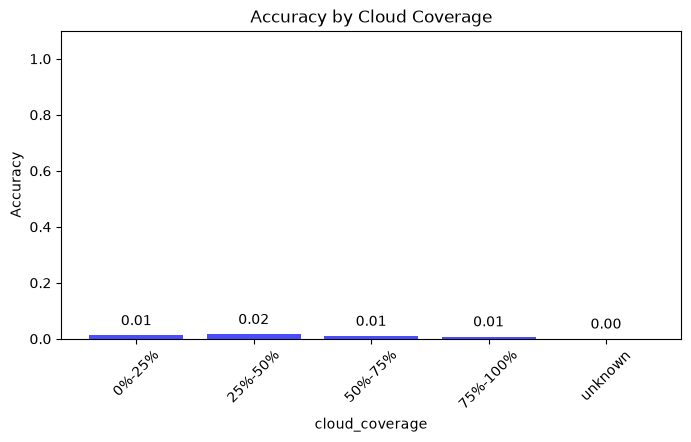

In [124]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

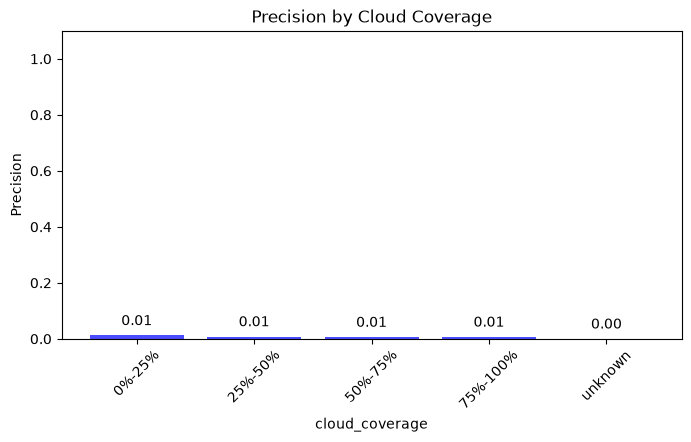

In [125]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

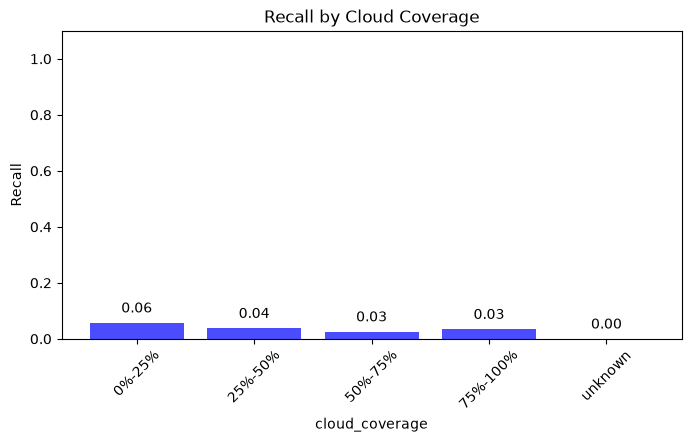

In [126]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

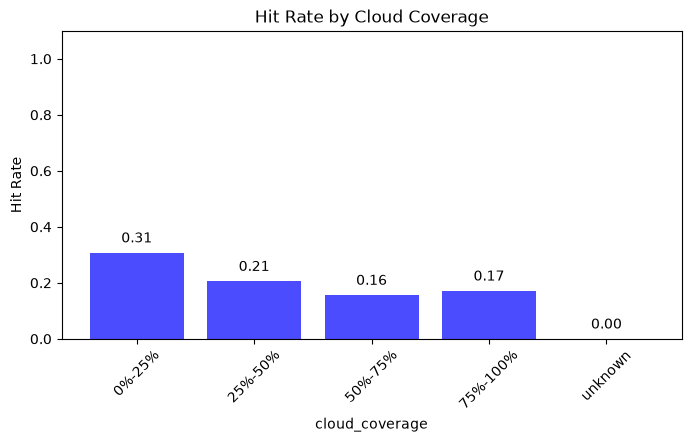

In [127]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

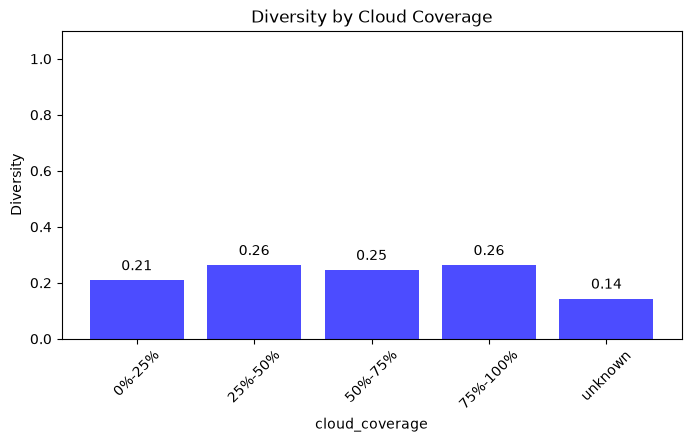

In [128]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

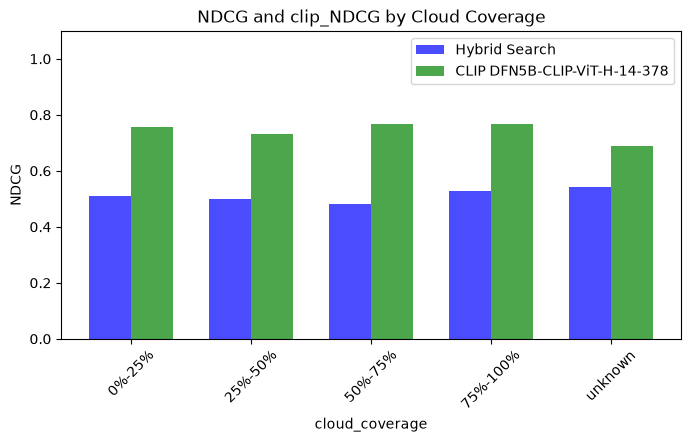

In [129]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

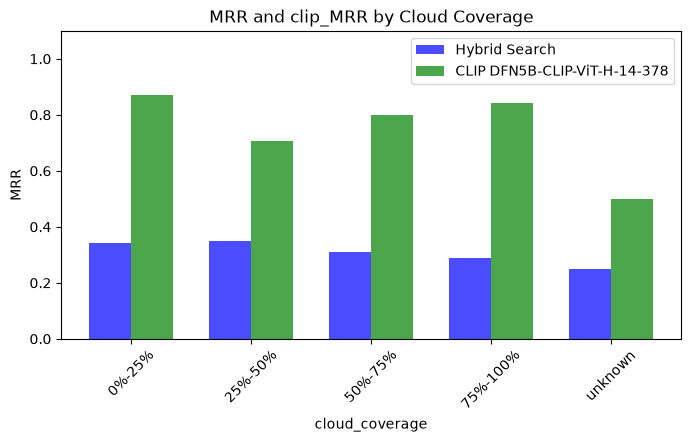

In [130]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Viewpoint

In [131]:
# Group
view_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
view_metrics = view_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = view_metrics
x_column = 'viewpoint'
title = 'Viewpoint'

metrics

,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,fisheye_sky,975,11,964,5,970,0.011282,0.005128,0.024786,0.128205,0.504909,0.711118,0.283771,0.756838,0.246599
1,ground_horizontal,1175,13,1162,10,1165,0.011064,0.008511,0.046150,0.212766,0.493998,0.796685,0.345537,0.826950,0.254981
2,ground_upward,675,7,668,5,670,0.010370,0.007407,0.022163,0.185185,0.523491,0.743100,0.327279,0.756597,0.249094
3,oblique,25,1,24,1,24,0.040000,0.040000,0.200000,1.000000,0.536806,0.804105,0.200000,1.000000,0.314381
4,other,25,1,24,1,24,0.040000,0.040000,0.125000,1.000000,0.491542,0.806752,0.250000,1.000000,0.172522


### Accuracy

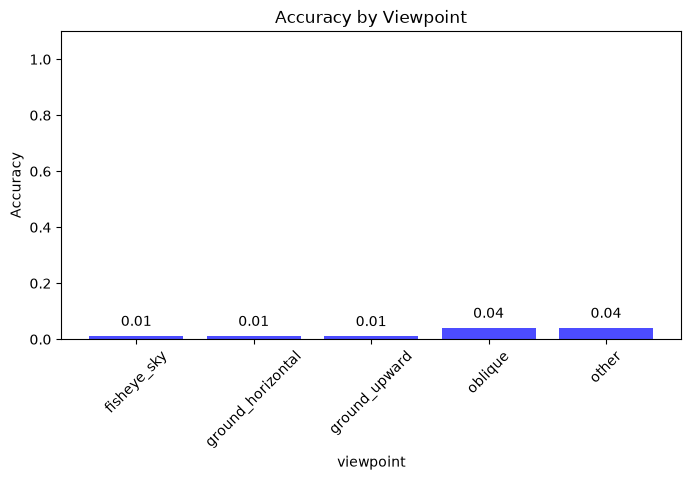

In [132]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

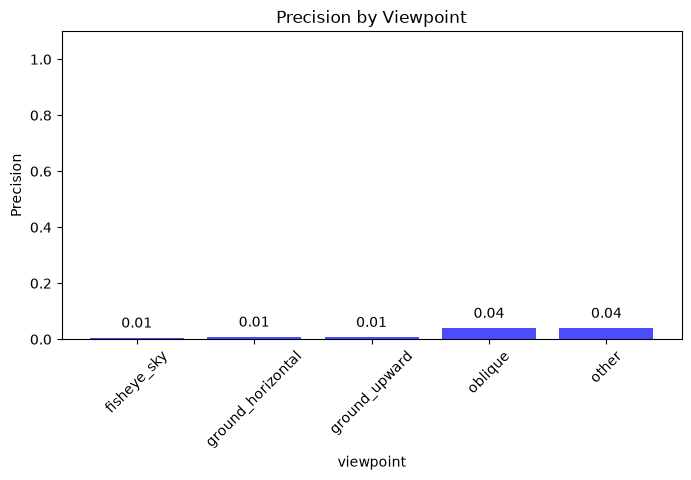

In [133]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

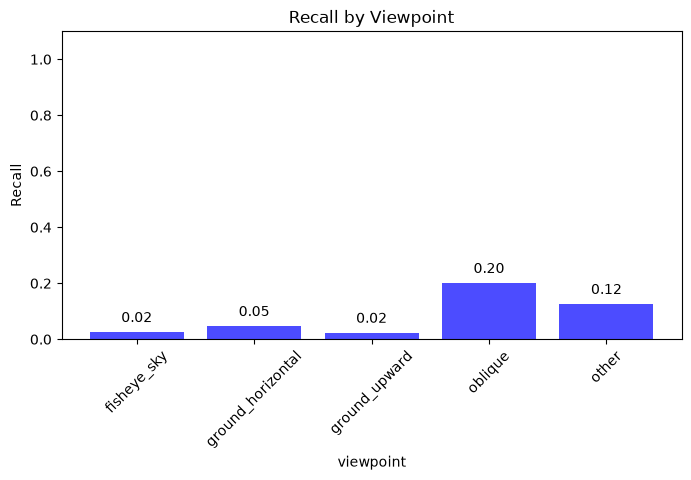

In [134]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

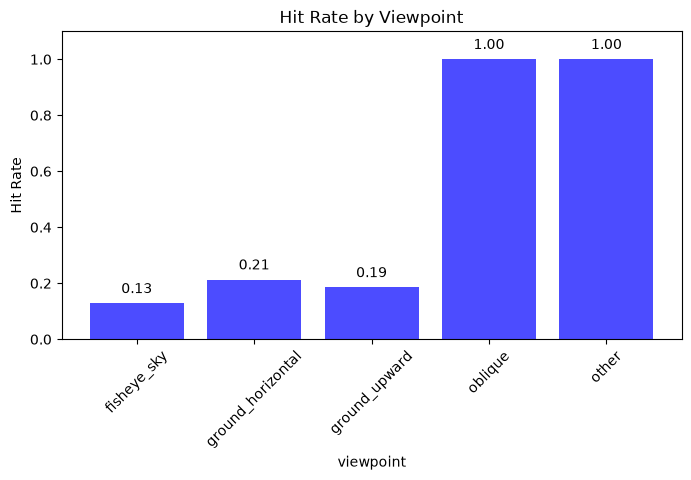

In [135]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

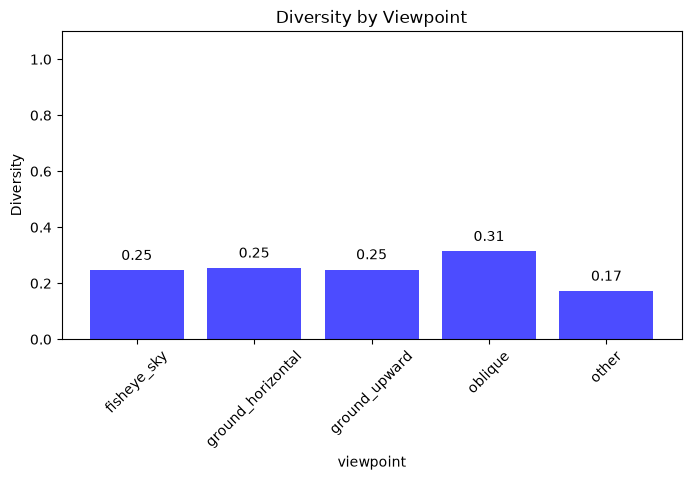

In [136]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

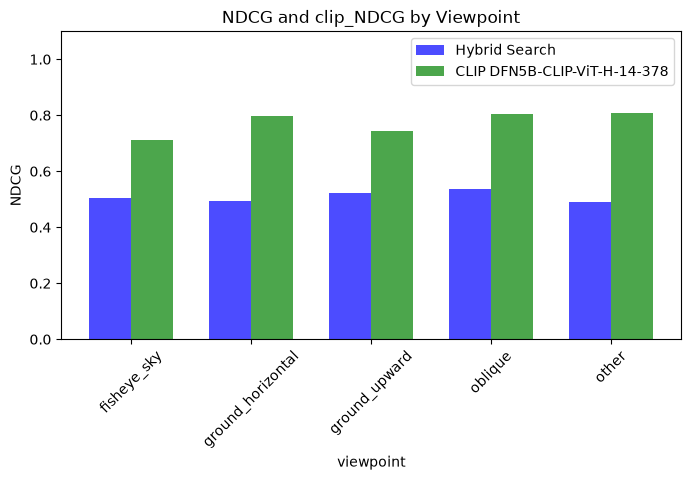

In [137]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

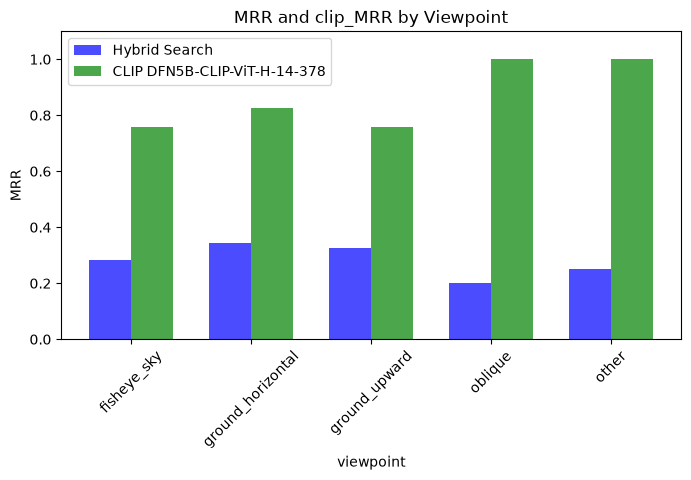

In [138]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Lighting

In [139]:
# Group
lighting_metrics = df.groupby(['lighting']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
lighting_metrics = lighting_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = lighting_metrics
x_column = 'lighting'
title = 'Lighting'

metrics

,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,bright,275,3,272,1,274,0.010909,0.003636,0.012987,0.090909,0.562594,0.743907,0.429798,0.687229,0.277768
1,day,1250,17,1233,13,1237,0.013600,0.010400,0.043659,0.260000,0.460300,0.741568,0.273694,0.768705,0.255180
2,dusk,400,4,396,2,398,0.010000,0.005000,0.014063,0.125000,0.522199,0.789225,0.344172,0.819792,0.269054
3,night,650,6,644,3,647,0.009231,0.004615,0.025962,0.115385,0.522910,0.735738,0.319446,0.783333,0.197250
4,overcast_light,300,3,297,3,297,0.010000,0.010000,0.069444,0.250000,0.576467,0.819516,0.364087,0.944444,0.297173


### Accuracy

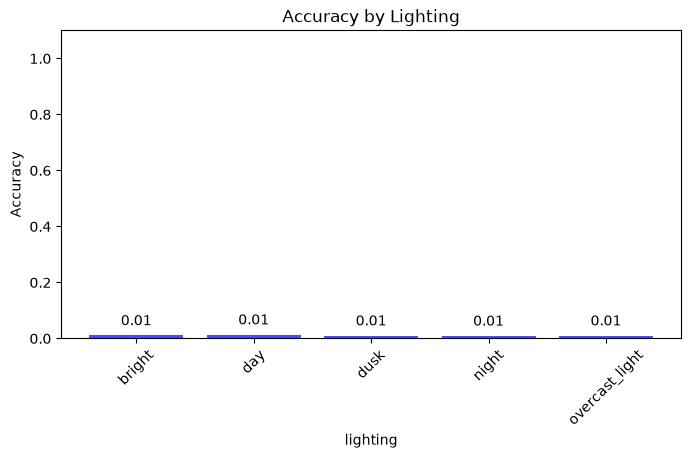

In [140]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

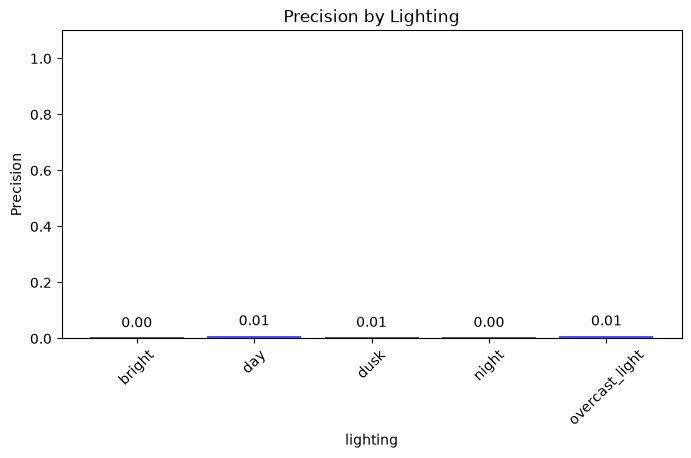

In [141]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

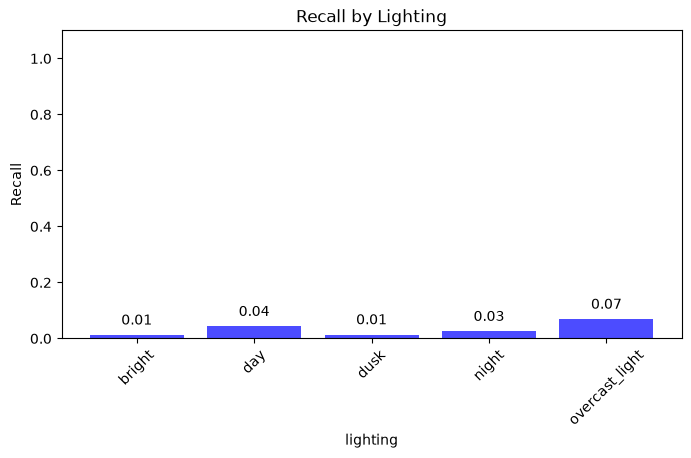

In [142]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

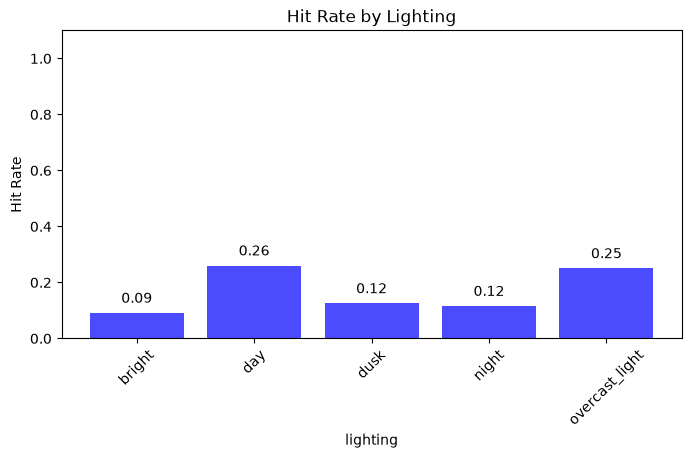

In [143]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

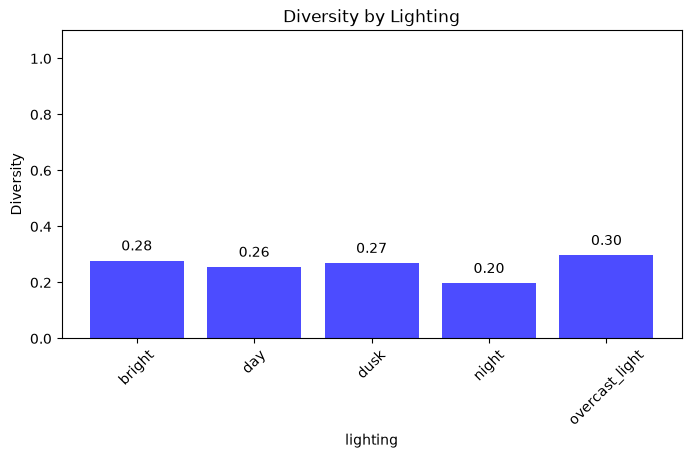

In [144]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

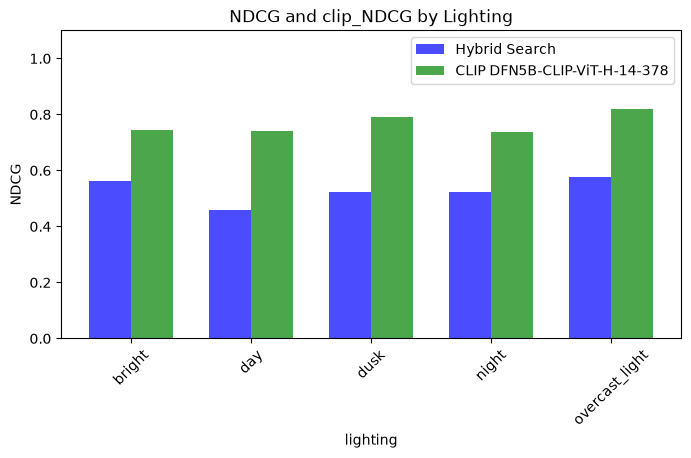

In [145]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

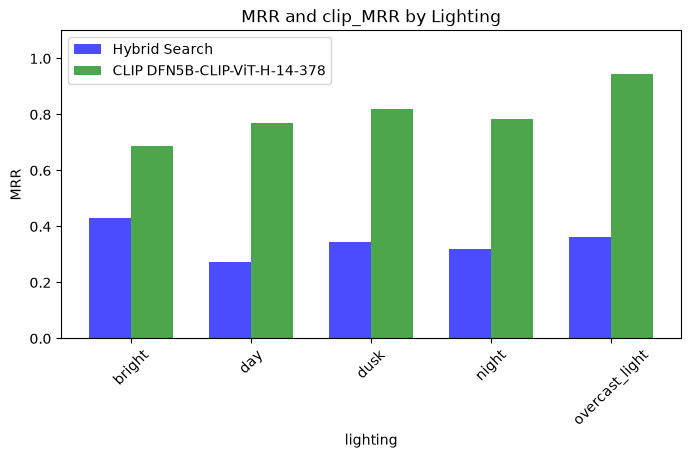

In [146]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Confounder Type

In [147]:
# Group
confounder_metrics = df.groupby('confounder_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
confounder_metrics = confounder_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = confounder_metrics
x_column = 'confounder_type'
title = 'Confounder Type'

metrics

,confounder_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,fog,25,1,24,1,24,0.040000,0.040000,0.200000,1.000000,0.536806,0.804105,0.200000,1.000000,0.314381
1,none,2200,23,2177,17,2183,0.010455,0.007727,0.038158,0.193182,0.497736,0.758388,0.319158,0.786575,0.254273
2,sun_glare,600,9,591,4,596,0.015000,0.006667,0.020883,0.166667,0.533711,0.748829,0.332622,0.795536,0.243744
3,unknown,50,0,50,0,50,0.000000,0.000000,0.000000,0.000000,0.462657,0.669103,0.162500,0.750000,0.136790


### Accuracy

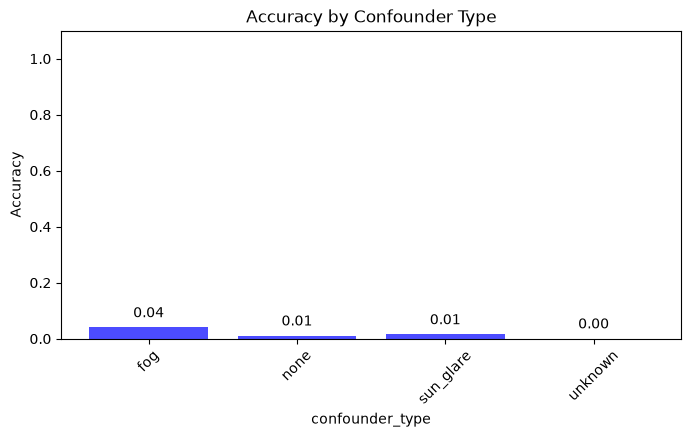

In [148]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

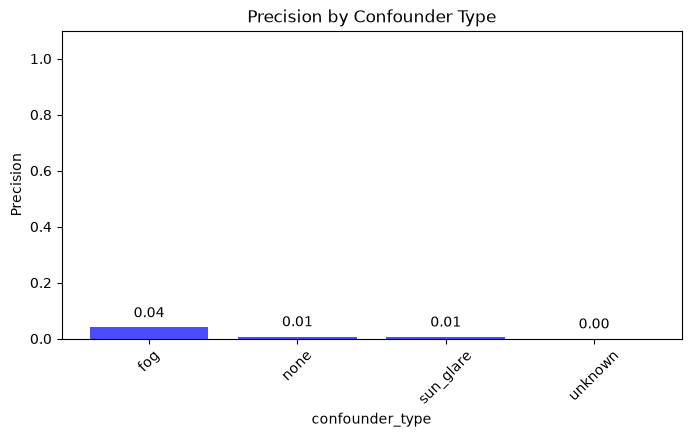

In [149]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

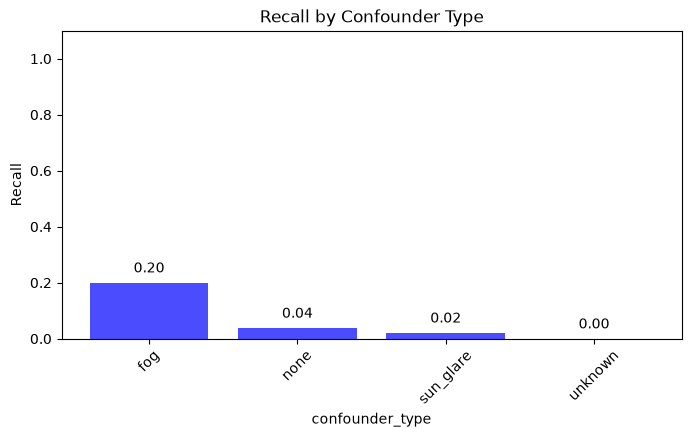

In [150]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

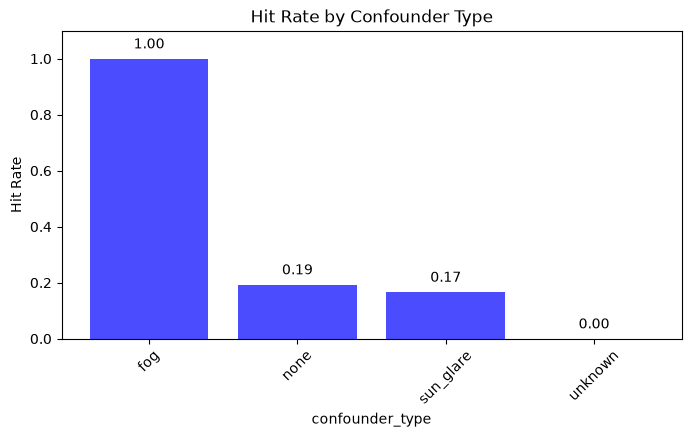

In [151]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

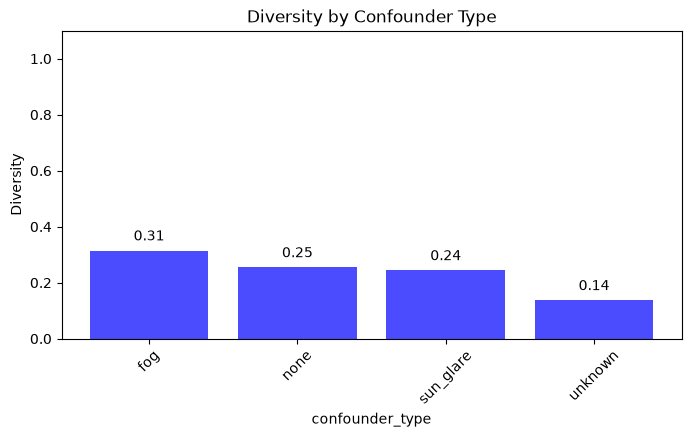

In [152]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

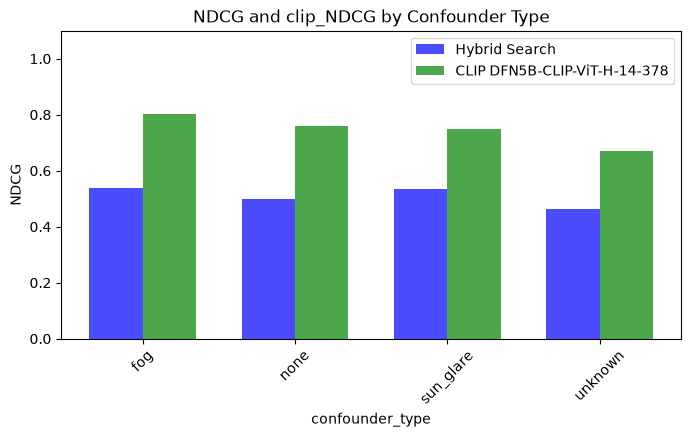

In [153]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

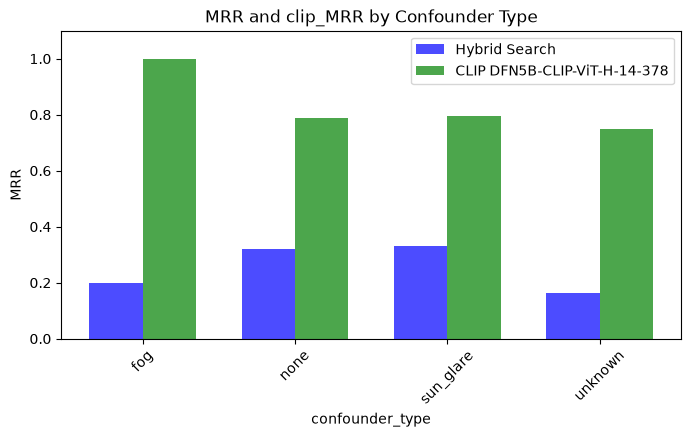

In [154]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Occlusion Present

In [155]:
# Group
occlusion_metrics = df.groupby('occlusion_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
occlusion_metrics['occlusion_present'] = occlusion_metrics['occlusion_present'].map({True: 'True', False: 'False'})

#rename columns
occlusion_metrics = occlusion_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = occlusion_metrics
x_column = 'occlusion_present'
title = 'Occlusion Present'

metrics

,occlusion_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1900,24,1876,17,1883,0.012632,0.008947,0.046392,0.223684,0.494652,0.770862,0.305642,0.805263,0.245496
1,True,975,9,966,5,970,0.009231,0.005128,0.013675,0.128205,0.525088,0.724791,0.342694,0.759268,0.260416


### Accuracy

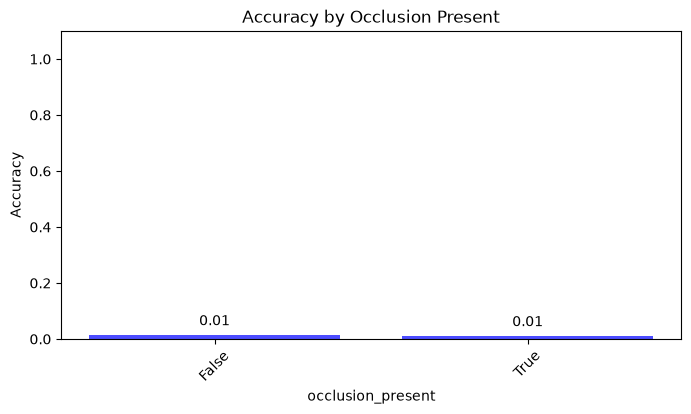

In [156]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

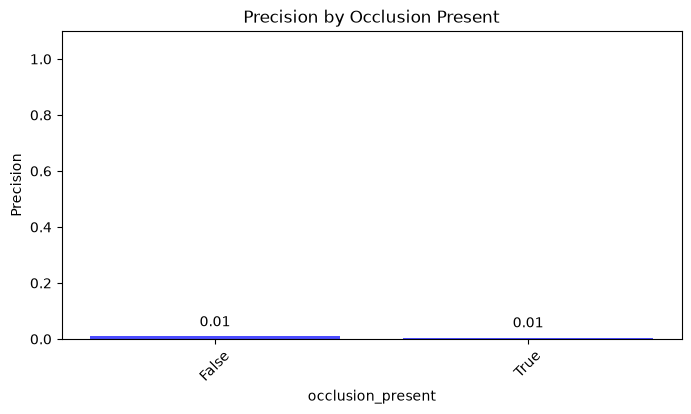

In [157]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

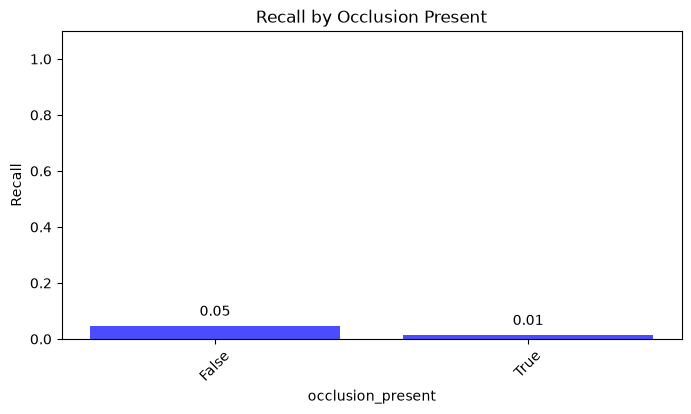

In [158]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

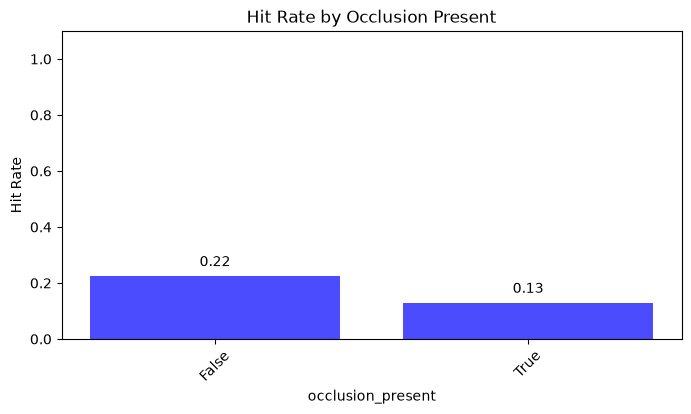

In [159]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

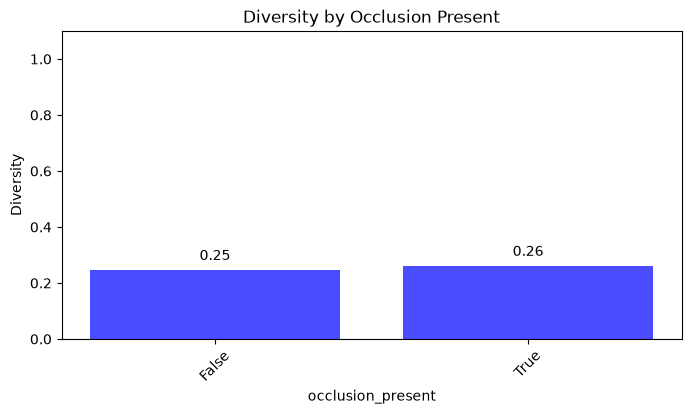

In [160]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

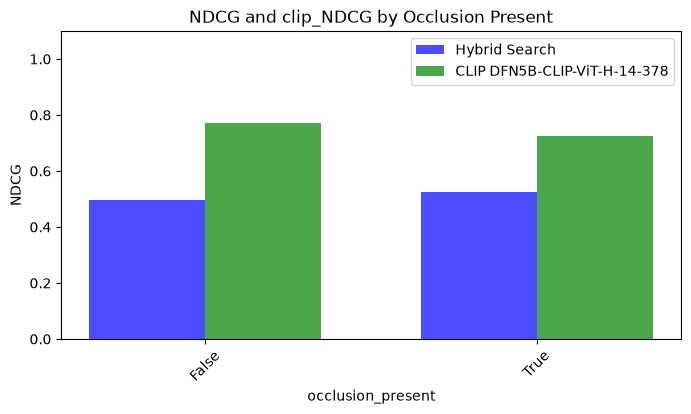

In [161]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

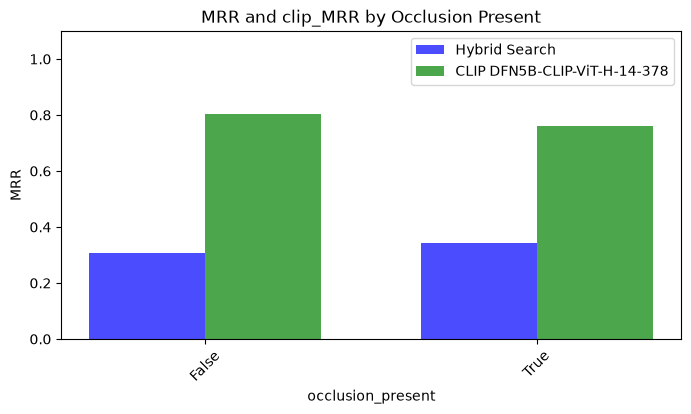

In [162]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Multiple Cloud Types

In [163]:
# Group
multiple_cloud_types_metrics = df.groupby('multiple_cloud_types').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
multiple_cloud_types_metrics['multiple_cloud_types'] = multiple_cloud_types_metrics['multiple_cloud_types'].map({True: 'True', False: 'False'})

#rename columns
multiple_cloud_types_metrics = multiple_cloud_types_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = multiple_cloud_types_metrics
x_column = 'multiple_cloud_types'
title = 'Multiple Cloud Types'

metrics

,multiple_cloud_types,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1700,20,1680,13,1687,0.011765,0.007647,0.037237,0.191176,0.50338,0.742099,0.289369,0.766082,0.239061
1,True,1175,13,1162,9,1166,0.011064,0.007660,0.032489,0.191489,0.50728,0.774247,0.359931,0.823784,0.267186


### Accuracy

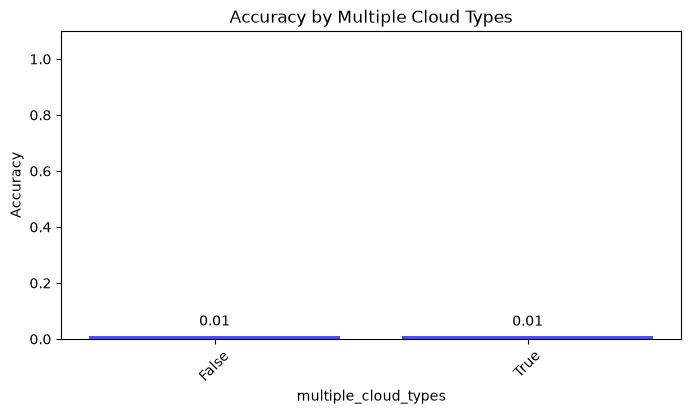

In [164]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

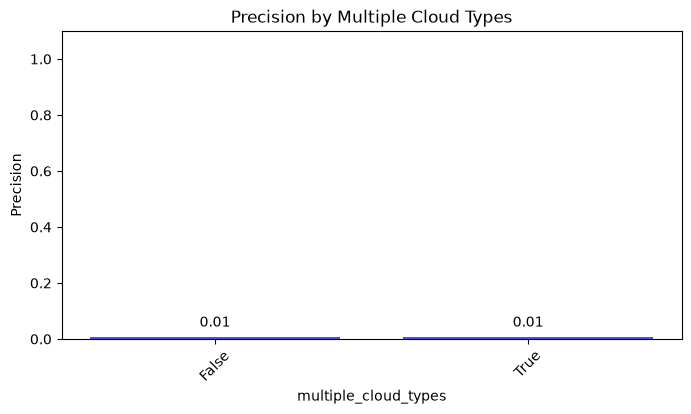

In [165]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

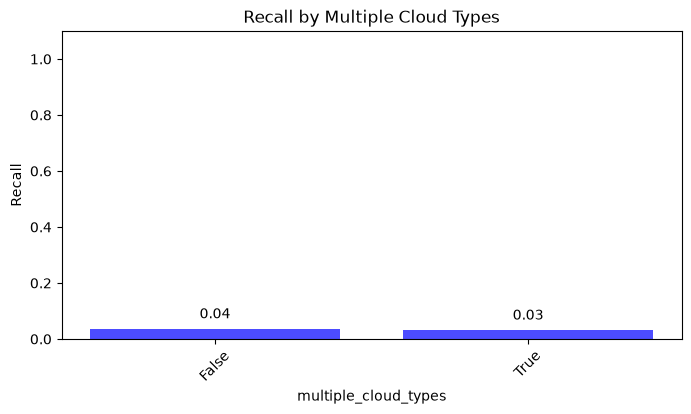

In [166]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

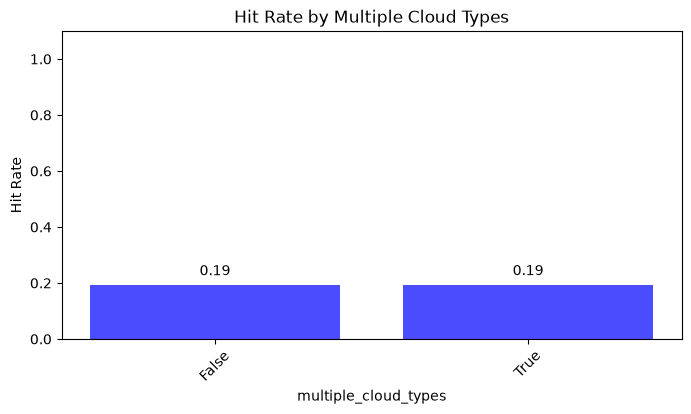

In [167]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

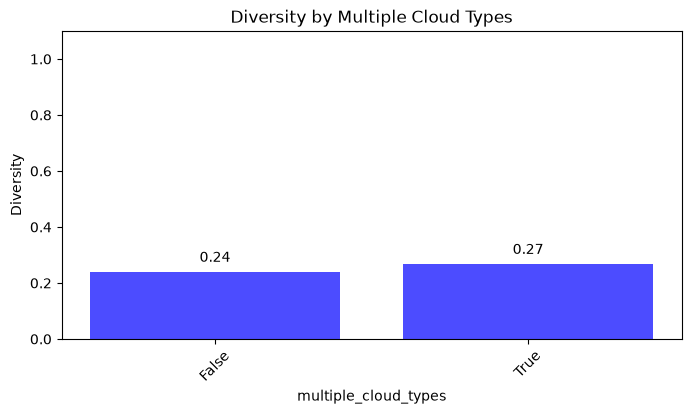

In [168]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

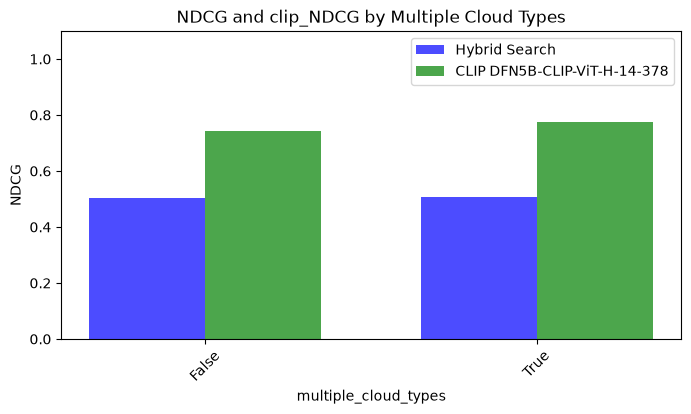

In [169]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

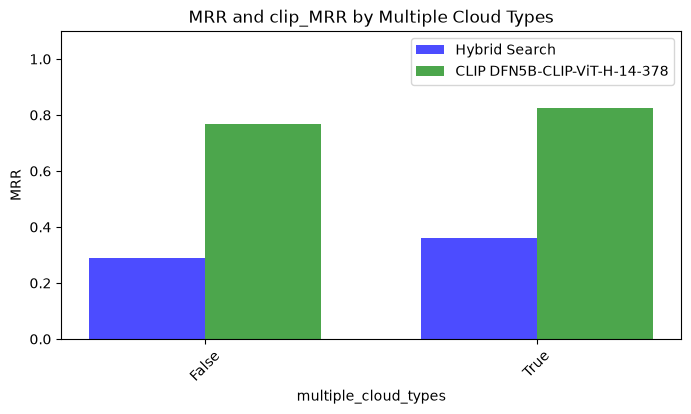

In [170]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Horizon Visible

In [171]:
# Group
horizon_visible_metrics = df.groupby('horizon_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
horizon_visible_metrics['horizon_visible'] = horizon_visible_metrics['horizon_visible'].map({True: 'True', False: 'False'})

#rename columns
horizon_visible_metrics = horizon_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = horizon_visible_metrics
x_column = 'horizon_visible'
title = 'Horizon Visible'

metrics

,horizon_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,600,12,588,8,592,0.020000,0.013333,0.066650,0.333333,0.525139,0.751552,0.367134,0.716400,0.232190
1,True,2275,21,2254,14,2261,0.009231,0.006154,0.027028,0.153846,0.499655,0.756210,0.305304,0.808987,0.255399


### Accuracy

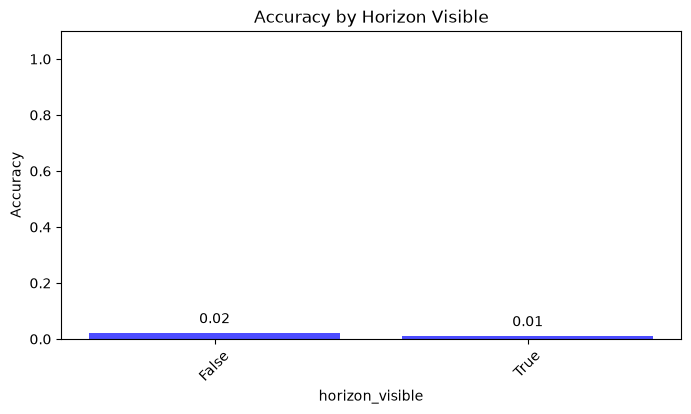

In [172]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

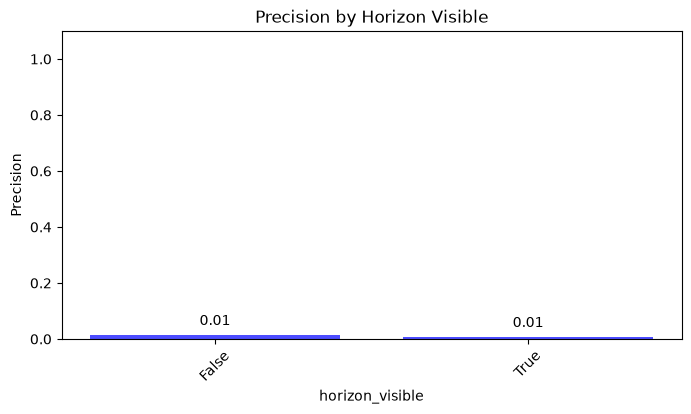

In [173]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

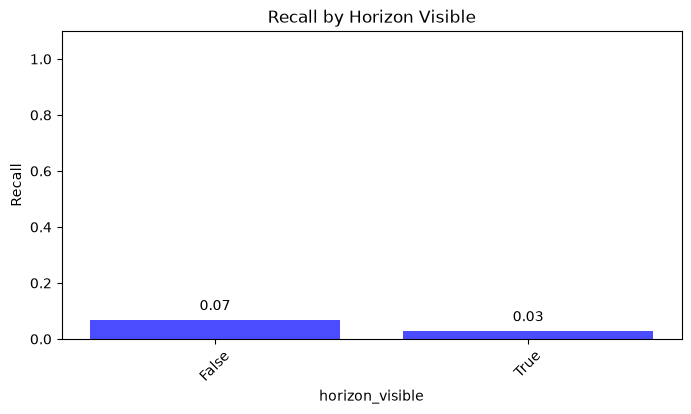

In [174]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

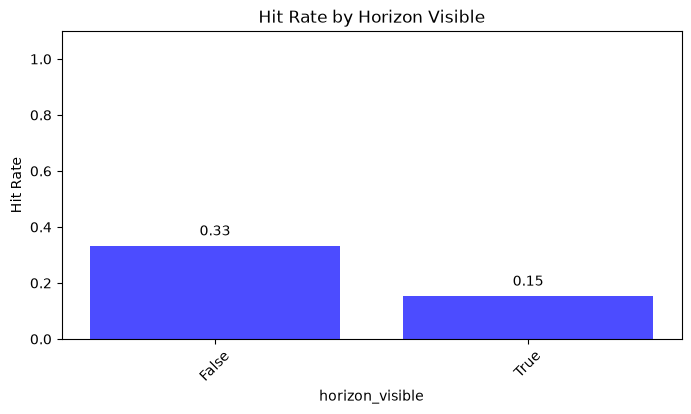

In [175]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

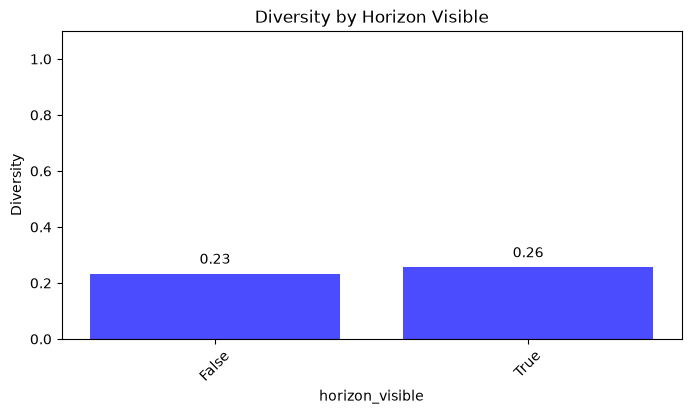

In [176]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

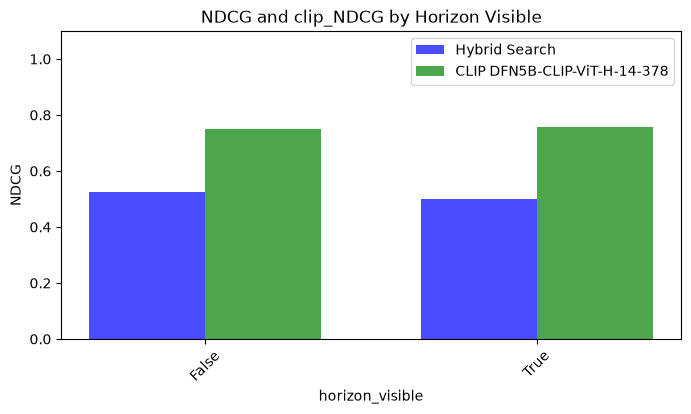

In [177]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

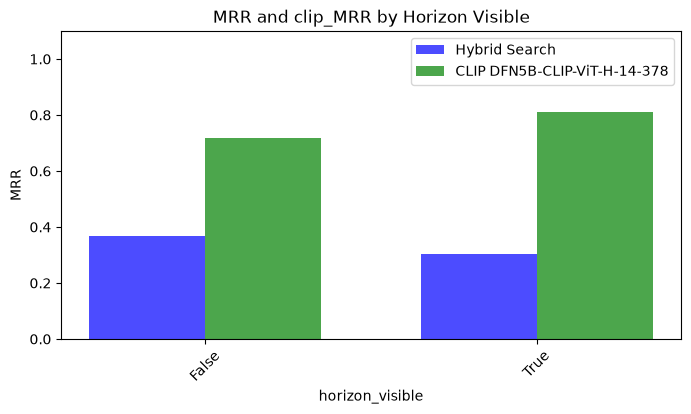

In [178]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Ground Visible

In [179]:
# Group
ground_visible_metrics = df.groupby('ground_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
ground_visible_metrics['ground_visible'] = ground_visible_metrics['ground_visible'].map({True: 'True', False: 'False'})

#rename columns
ground_visible_metrics = ground_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = ground_visible_metrics
x_column = 'ground_visible'
title = 'Ground Visible'

metrics

,ground_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,475,9,466,6,469,0.018947,0.012632,0.071846,0.315789,0.490592,0.772632,0.306354,0.791228,0.243883
1,True,2400,24,2376,16,2384,0.010000,0.006667,0.028063,0.166667,0.507820,0.751795,0.320553,0.789355,0.251876


### Accuracy

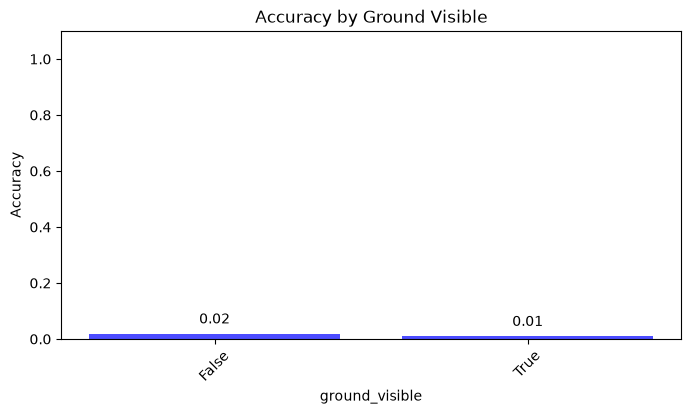

In [180]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

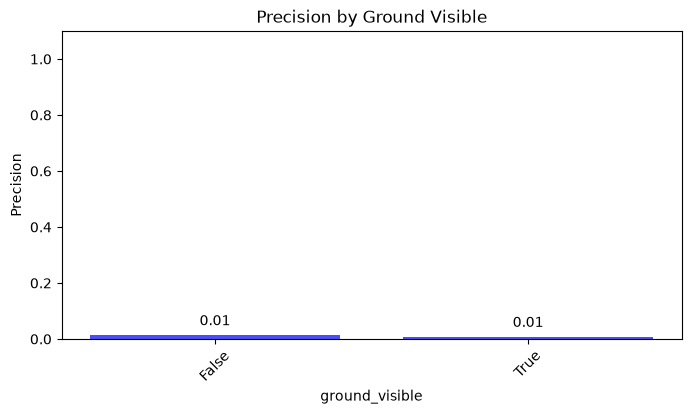

In [181]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

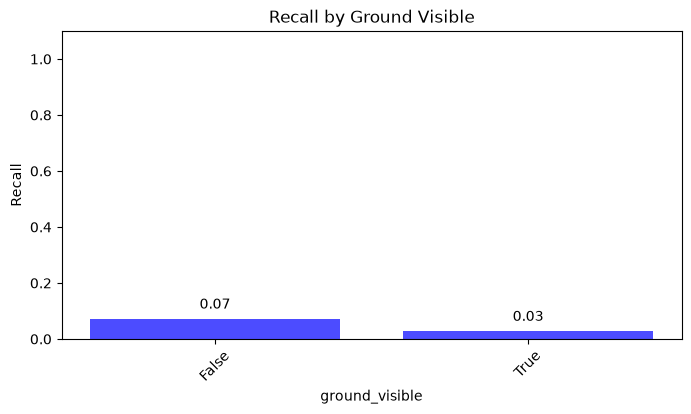

In [182]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

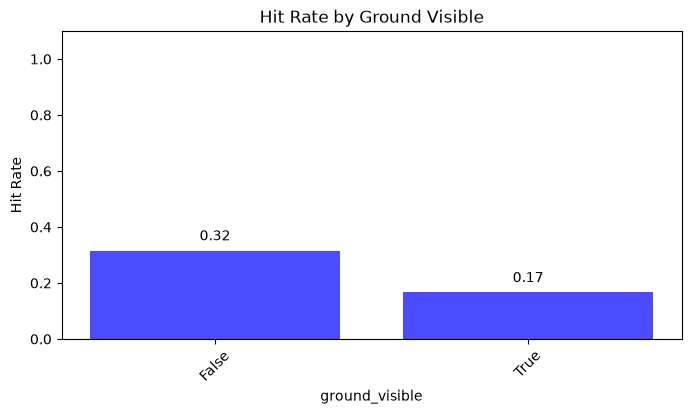

In [183]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

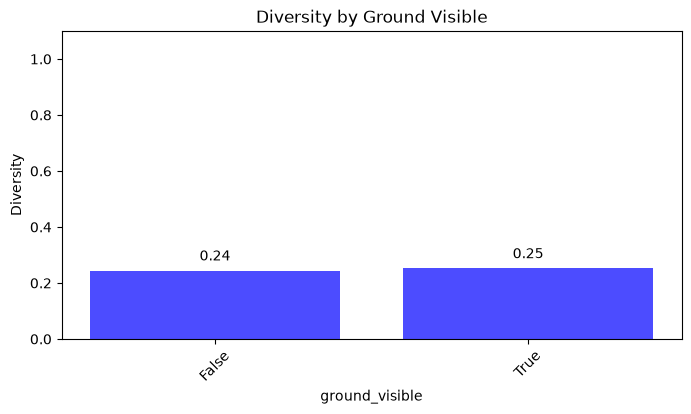

In [184]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

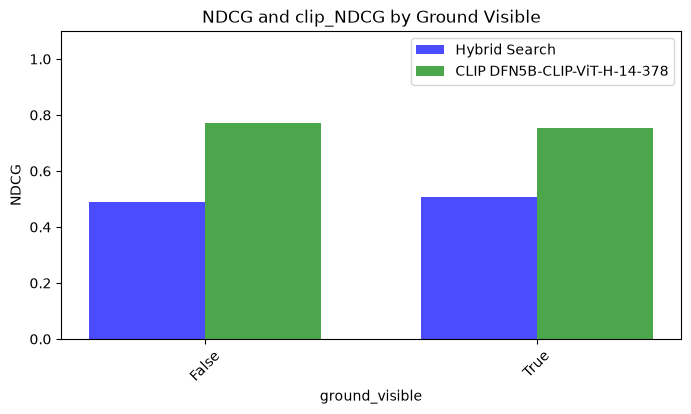

In [185]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

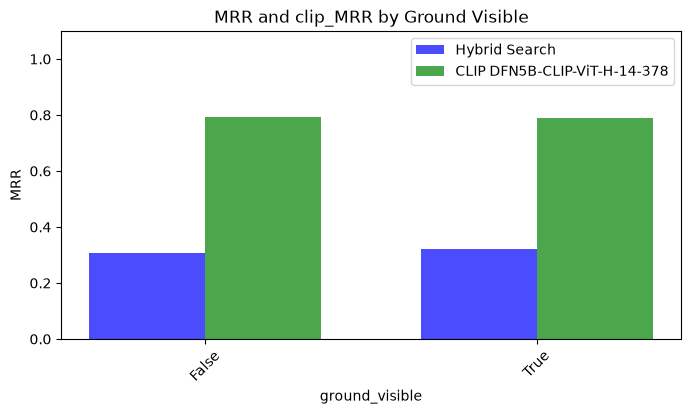

In [186]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Sun Visible

In [187]:
# Group
sun_visible_metrics = df.groupby('sun_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
sun_visible_metrics['sun_visible'] = sun_visible_metrics['sun_visible'].map({True: 'True', False: 'False'})

#rename columns
sun_visible_metrics = sun_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = sun_visible_metrics
x_column = 'sun_visible'
title = 'Sun Visible'

metrics

,sun_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2450,26,2424,18,2432,0.010612,0.007347,0.036305,0.183673,0.499844,0.759479,0.314494,0.801550,0.249517
1,True,425,7,418,4,421,0.016471,0.009412,0.029482,0.235294,0.534547,0.730789,0.339613,0.721148,0.256540


### Accuracy

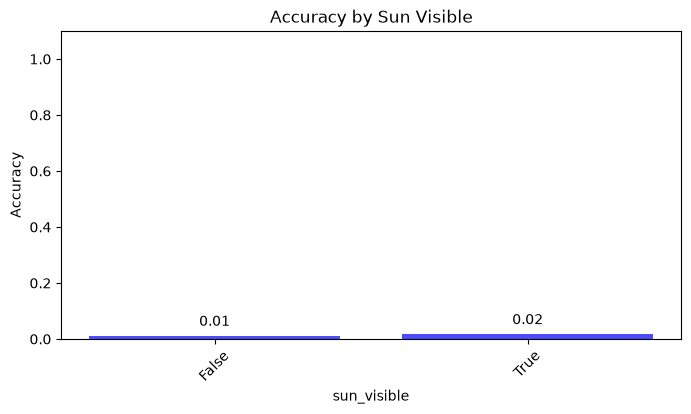

In [188]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

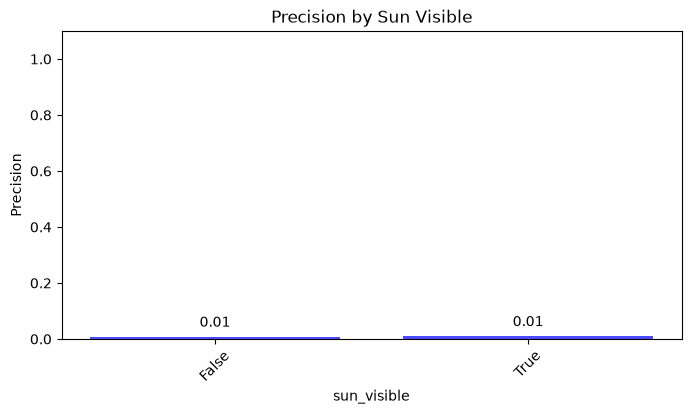

In [189]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

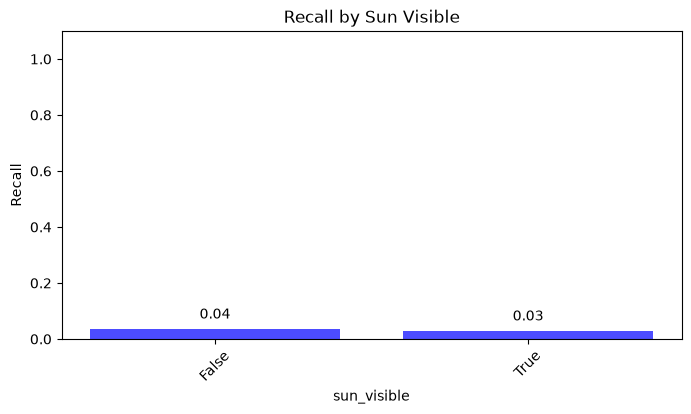

In [190]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

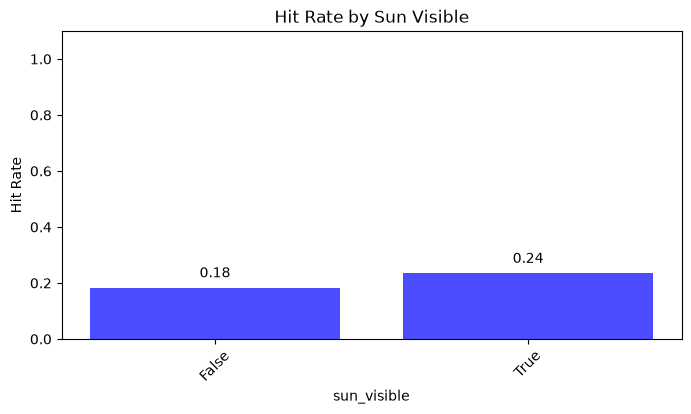

In [191]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

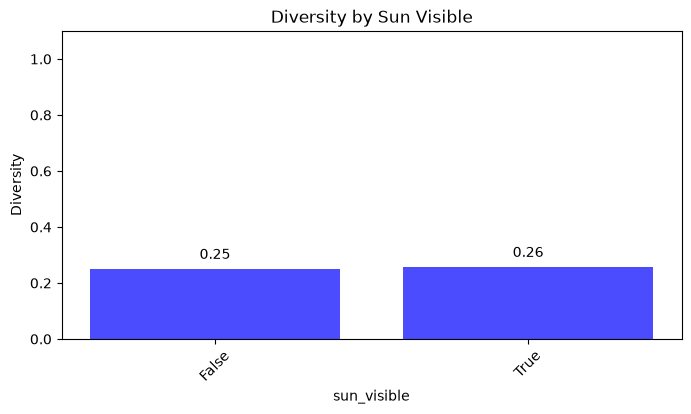

In [192]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

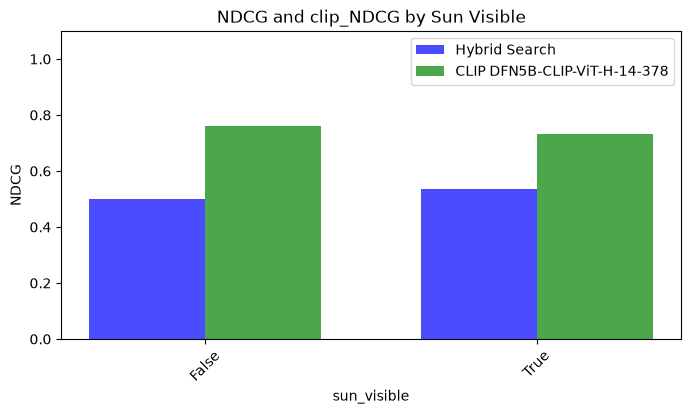

In [193]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

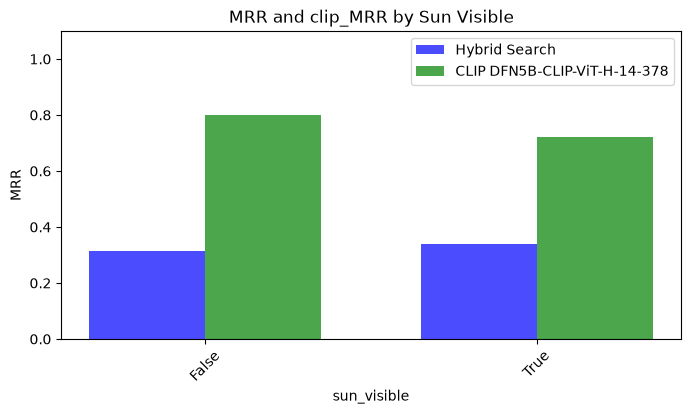

In [194]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Precipitation Visible

In [195]:
# Group
precipitation_visible_metrics = df.groupby('precipitation_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
precipitation_visible_metrics['precipitation_visible'] = precipitation_visible_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
precipitation_visible_metrics = precipitation_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = precipitation_visible_metrics
x_column = 'precipitation_visible'
title = 'Precipitation Visible'

metrics

,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2800,31,2769,20,2780,0.011071,0.007143,0.033181,0.178571,0.507697,0.749329,0.321104,0.784031,0.252066
1,True,75,2,73,2,73,0.026667,0.026667,0.114286,0.666667,0.403319,0.975833,0.210084,1.000000,0.194178


### Accuracy

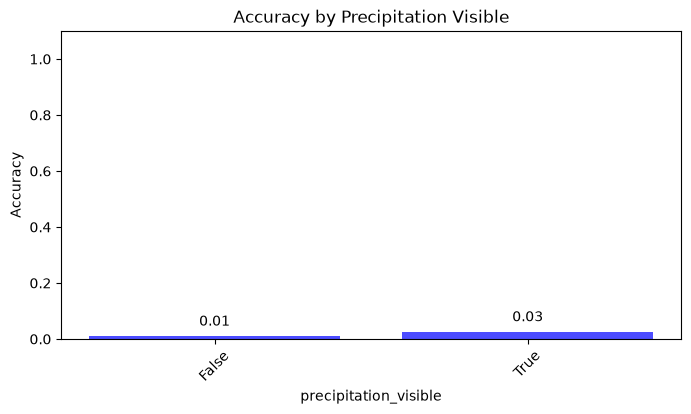

In [196]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

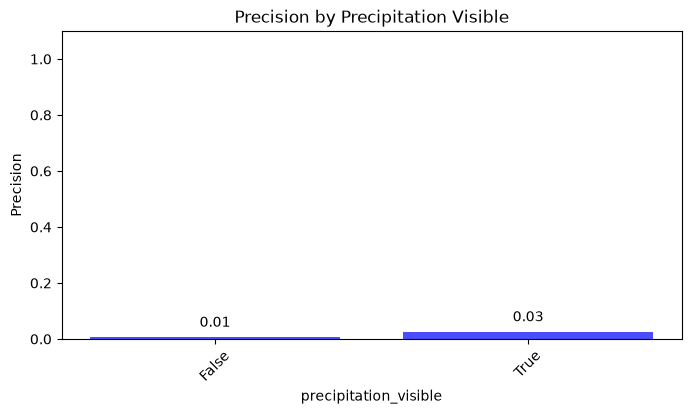

In [197]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

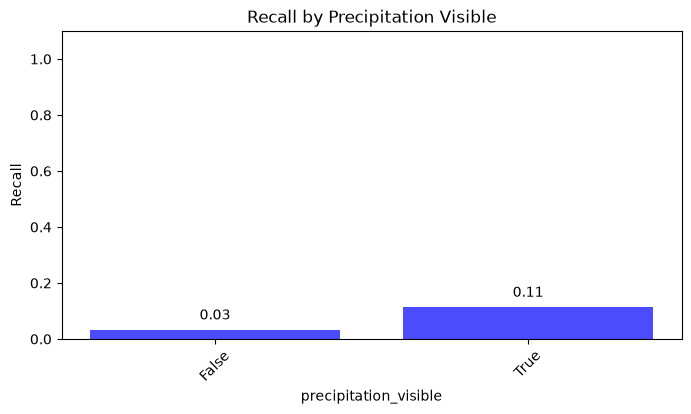

In [198]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

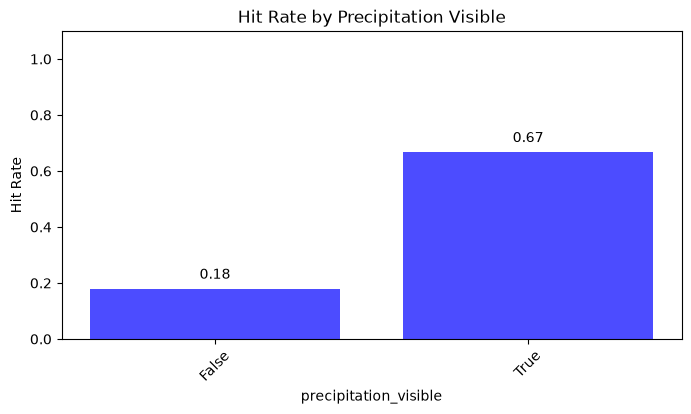

In [199]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

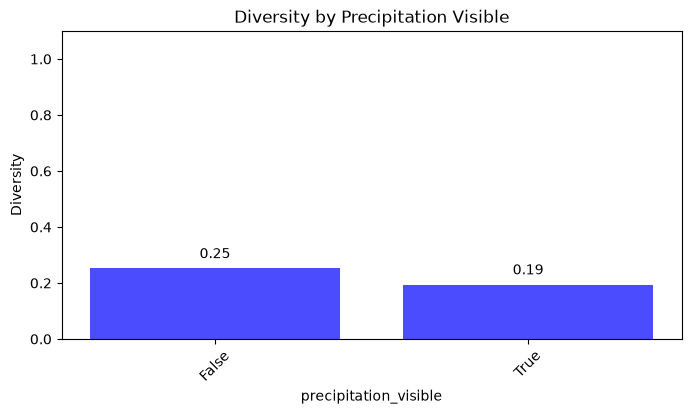

In [200]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

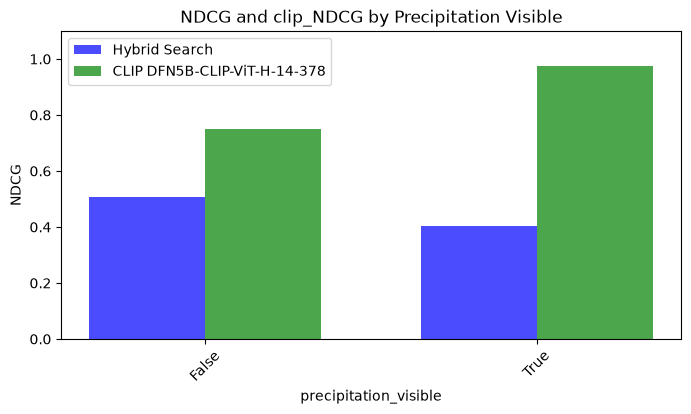

In [201]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

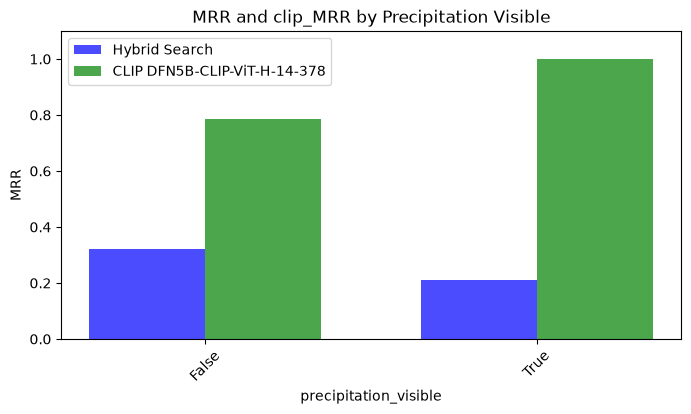

In [202]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Overcast

In [203]:
# Group
overcast_metrics = df.groupby('overcast').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
overcast_metrics['overcast'] = overcast_metrics['overcast'].map({True: 'True', False: 'False'})

#rename columns
overcast_metrics = overcast_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = overcast_metrics
x_column = 'overcast'
title = 'Overcast'

metrics

,overcast,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2275,28,2247,17,2258,0.012308,0.007473,0.032976,0.186813,0.500446,0.745534,0.334674,0.754338,0.244712
1,True,600,5,595,5,595,0.008333,0.008333,0.044097,0.208333,0.522142,0.792033,0.255772,0.923611,0.272711


### Accuracy

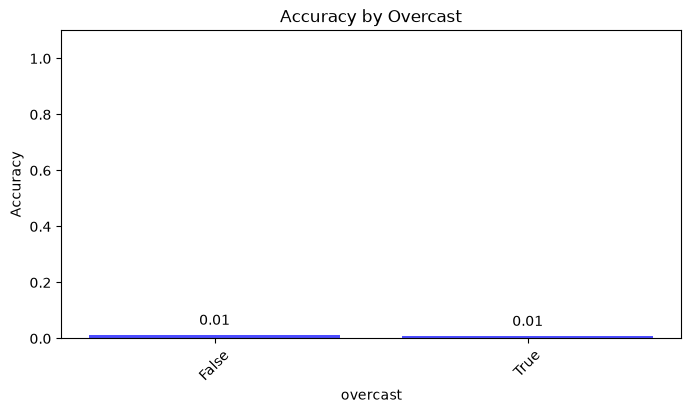

In [204]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

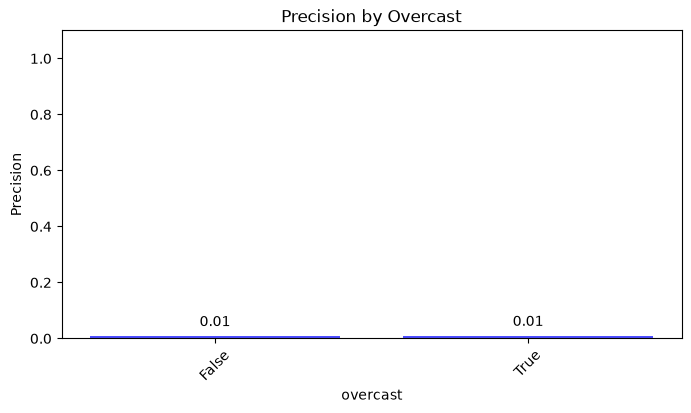

In [205]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

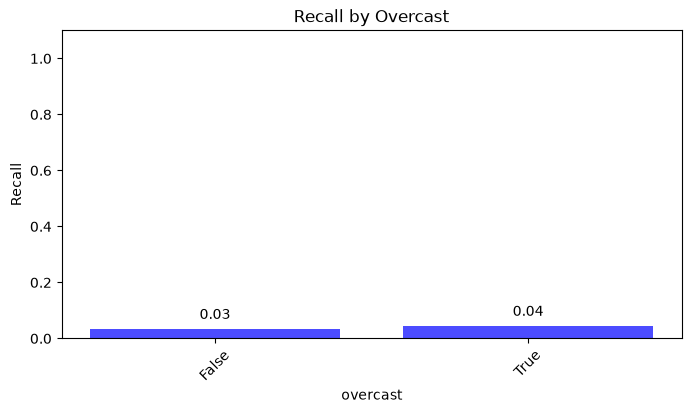

In [206]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

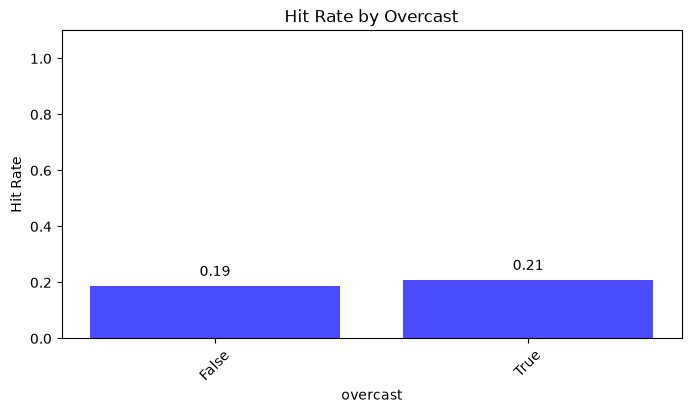

In [207]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

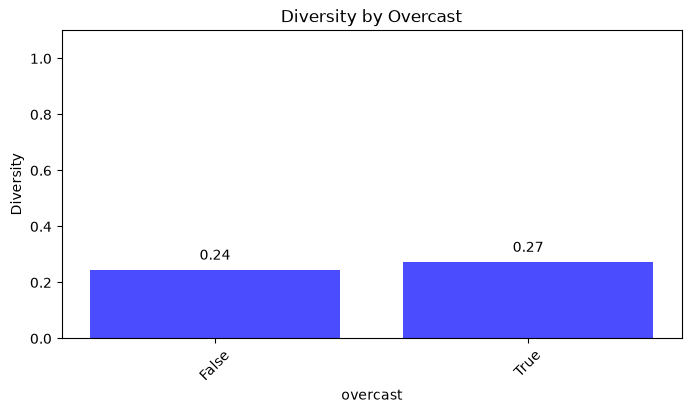

In [208]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

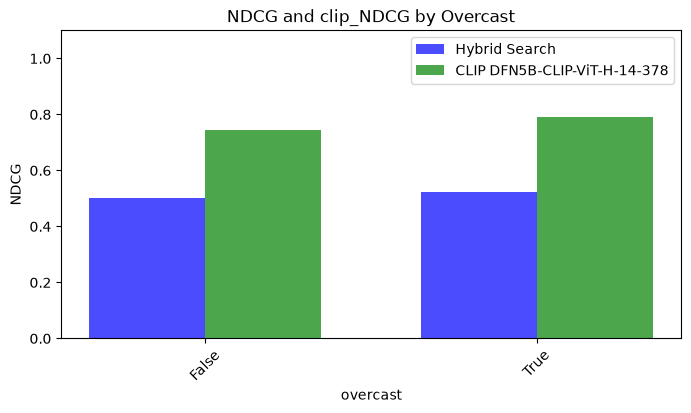

In [209]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

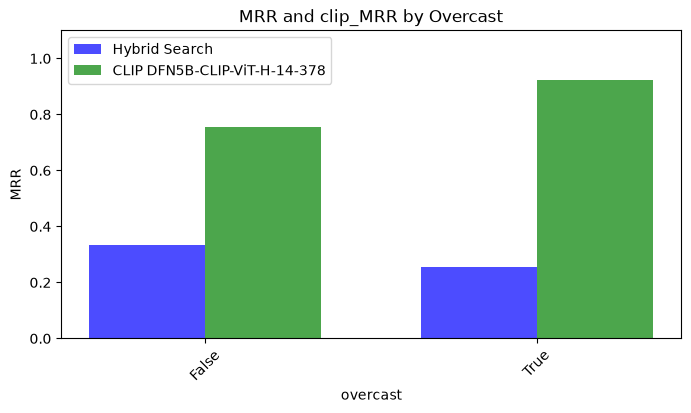

In [210]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Multiple Layers

In [211]:
# Group
multiple_layers_metrics = df.groupby('multiple_layers').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
multiple_layers_metrics['multiple_layers'] = multiple_layers_metrics['multiple_layers'].map({True: 'True', False: 'False'})

#rename columns
multiple_layers_metrics = multiple_layers_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = multiple_layers_metrics
x_column = 'multiple_layers'
title = 'Multiple Layers'

metrics

,multiple_layers,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1550,17,1533,10,1540,0.010968,0.006452,0.033698,0.161290,0.507137,0.728107,0.296519,0.762262,0.240833
1,True,1325,16,1309,12,1313,0.012075,0.009057,0.037167,0.226415,0.502443,0.786976,0.343579,0.821721,0.261929


### Accuracy

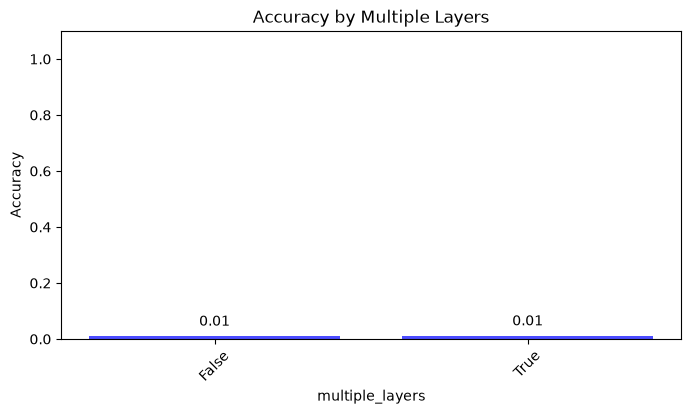

In [212]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

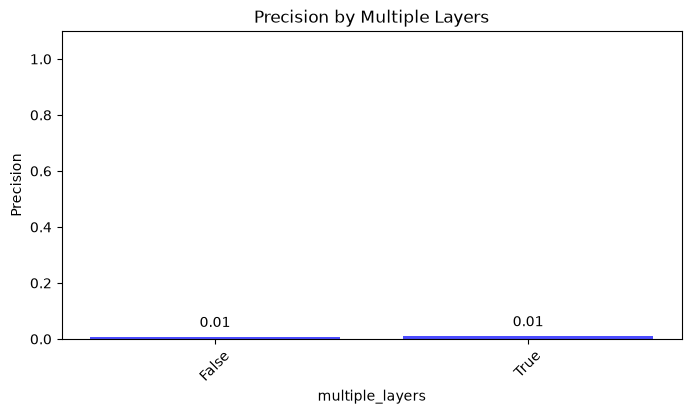

In [213]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

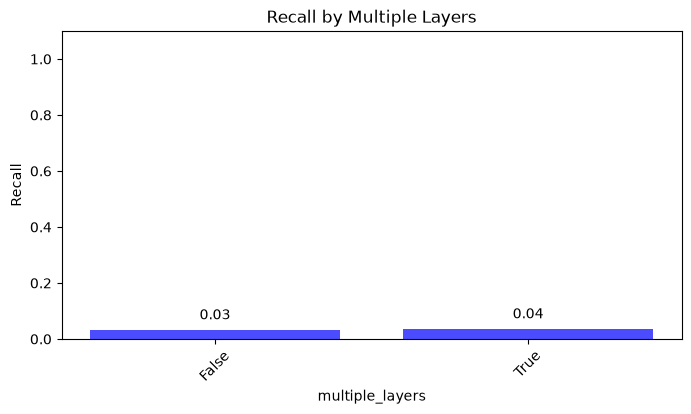

In [214]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

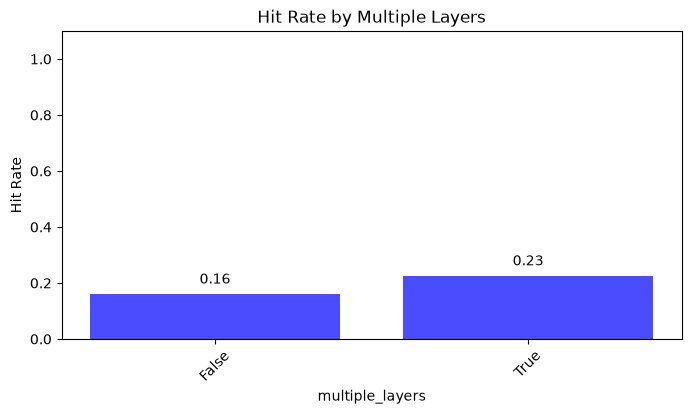

In [215]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

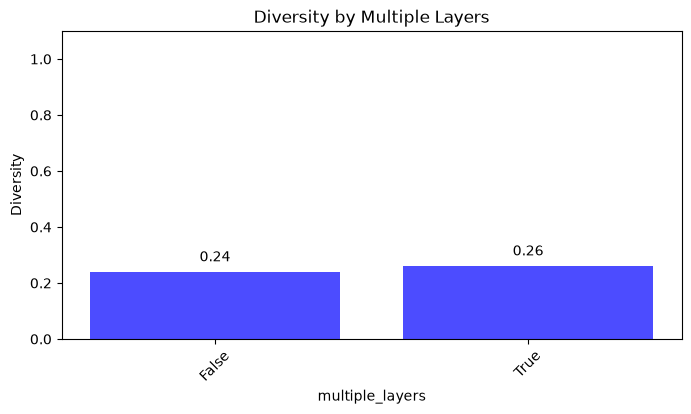

In [216]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

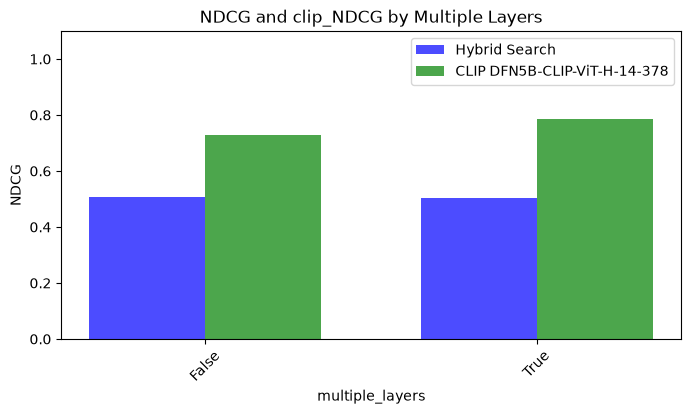

In [217]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

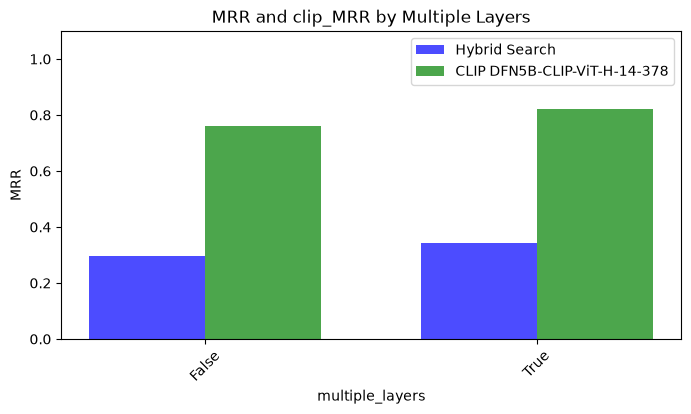

In [218]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Storm Visible

In [219]:
# Group
storm_visible_metrics = df.groupby('storm_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
storm_visible_metrics['storm_visible'] = storm_visible_metrics['storm_visible'].map({True: 'True', False: 'False'})

#rename columns
storm_visible_metrics = storm_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = storm_visible_metrics
x_column = 'storm_visible'
title = 'Storm Visible'

metrics

,storm_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2525,28,2497,17,2508,0.011089,0.006733,0.026363,0.168317,0.501337,0.742207,0.289787,0.777836,0.255993
1,True,350,5,345,5,345,0.014286,0.014286,0.099745,0.357143,0.531213,0.849247,0.523243,0.875000,0.211331


### Accuracy

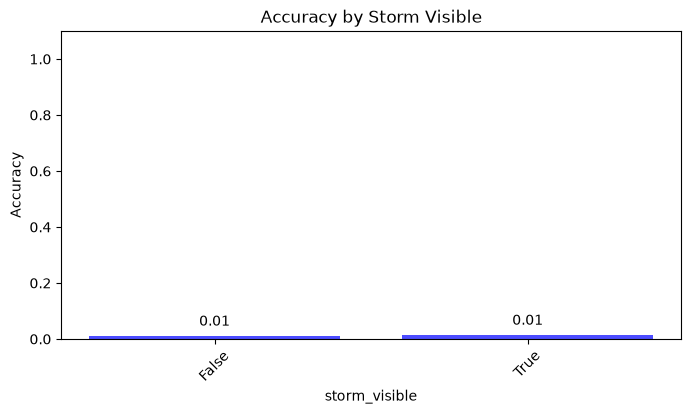

In [220]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

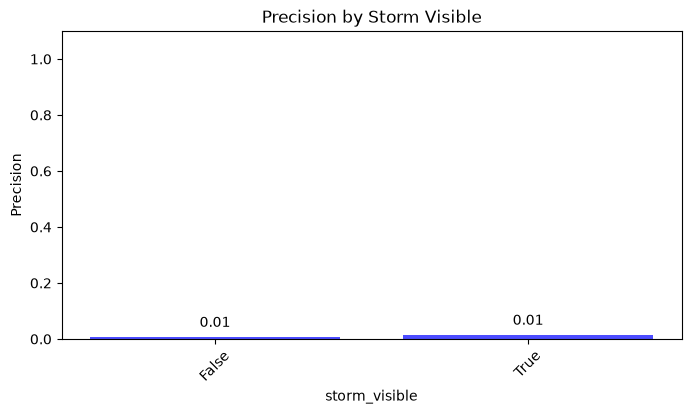

In [221]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

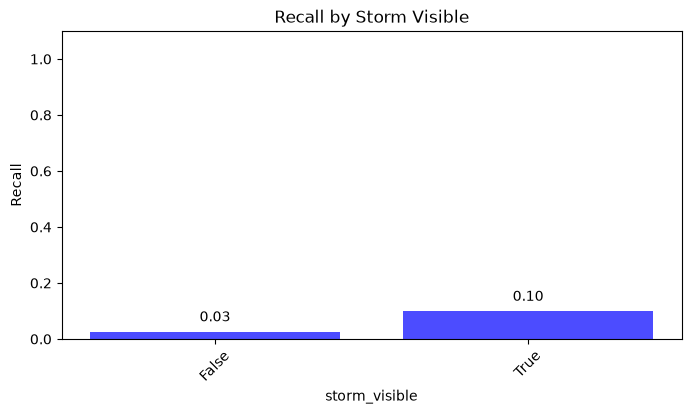

In [222]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

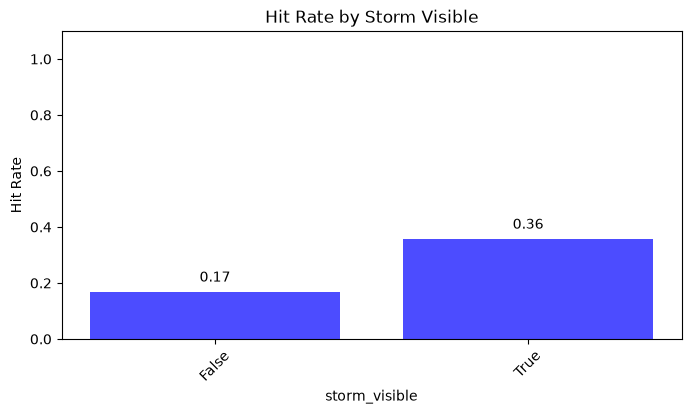

In [223]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

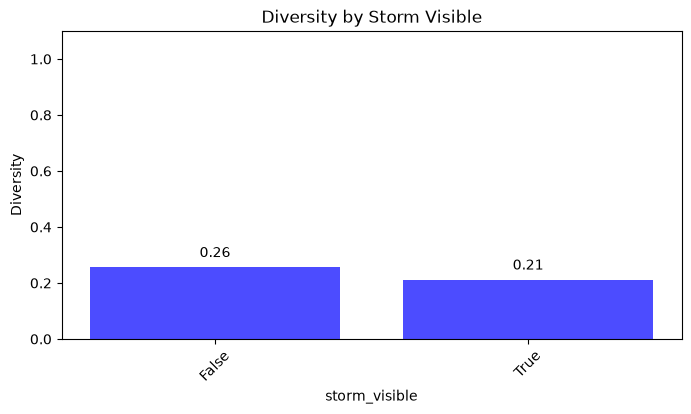

In [224]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

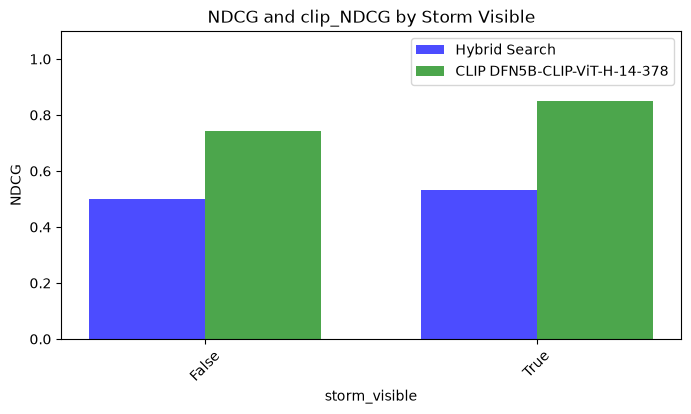

In [225]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

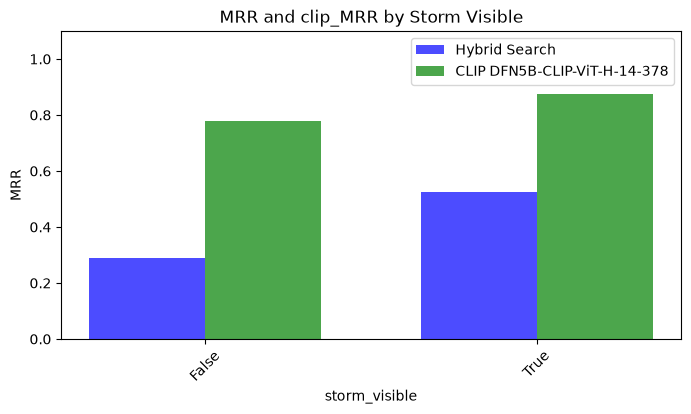

In [226]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Viewpoint & Sun Visible

Here we will group by Sun Visible and Viewpoint and calculate the sum/mean of each metric to see how the system performs under different Sun Visible and Viewpoint conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [227]:
# Group
view_sun_metrics = df.groupby(['viewpoint', 'sun_visible']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()
view_sun_metrics['sun_visible'] = view_sun_metrics['sun_visible'].map({True: 'True', False: 'False'})

#rename columns
view_sun_metrics = view_sun_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = view_sun_metrics
x_column = 'viewpoint'
group_column = 'sun_visible'
title = 'Viewpoint & Sun Visible'
colors = {
    "True": "red",
    "False": "green",
}

metrics

,viewpoint,sun_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,fisheye_sky,False,700,8,692,3,697,0.011429,0.004286,0.024107,0.107143,0.505493,0.706000,0.300666,0.755357,0.241400
1,fisheye_sky,True,275,3,272,2,273,0.010909,0.007273,0.026515,0.181818,0.503423,0.724145,0.240765,0.760606,0.259831
2,ground_horizontal,False,1150,13,1137,10,1140,0.011304,0.008696,0.047153,0.217391,0.489062,0.792972,0.331310,0.823188,0.256511
3,ground_horizontal,True,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.721061,0.967468,1.000000,1.000000,0.184599
4,ground_upward,False,550,3,547,3,547,0.005455,0.005455,0.017677,0.136364,0.513894,0.753334,0.305070,0.797057,0.245777
5,ground_upward,True,125,4,121,2,123,0.032000,0.016000,0.041905,0.400000,0.565718,0.698072,0.425000,0.578571,0.263688
6,oblique,False,25,1,24,1,24,0.040000,0.040000,0.200000,1.000000,0.536806,0.804105,0.200000,1.000000,0.314381
7,other,False,25,1,24,1,24,0.040000,0.040000,0.125000,1.000000,0.491542,0.806752,0.250000,1.000000,0.172522


### Accuracy

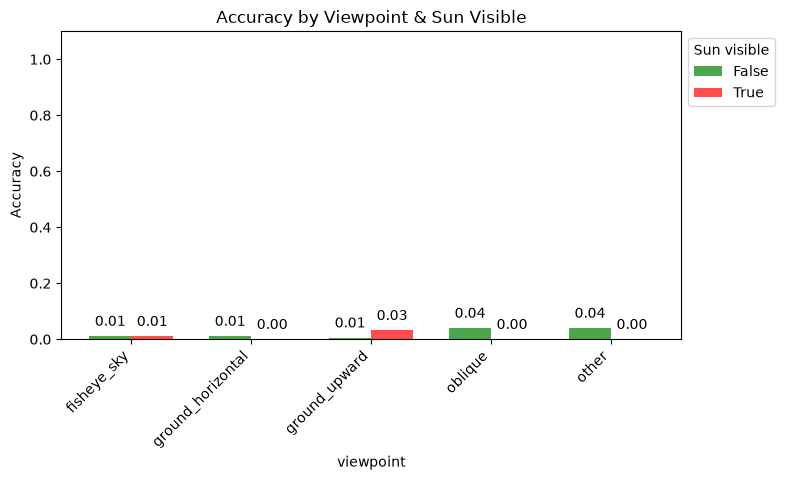

In [228]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='accuracy', 
    color_map=colors, 
    ylabel="Accuracy", 
    xlabel=x_column, 
    title=f"Accuracy by {title}",
)

### Precision

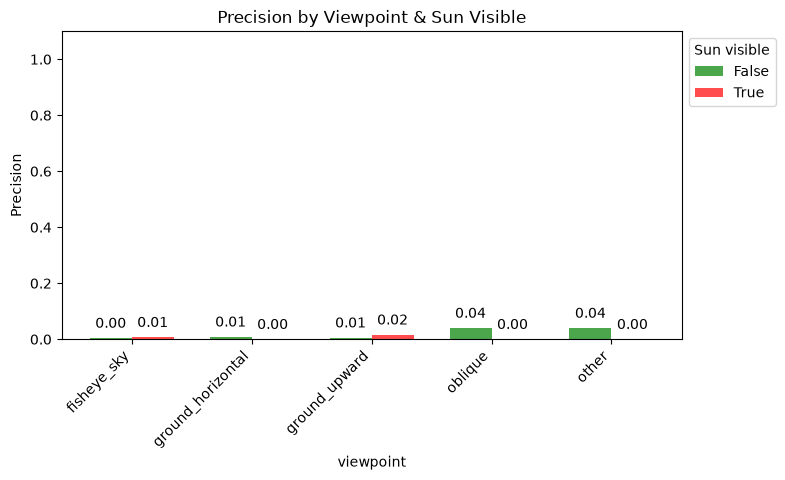

In [229]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='precision', 
    color_map=colors, 
    ylabel="Precision", 
    xlabel=x_column, 
    title=f"Precision by {title}",
)

### Recall

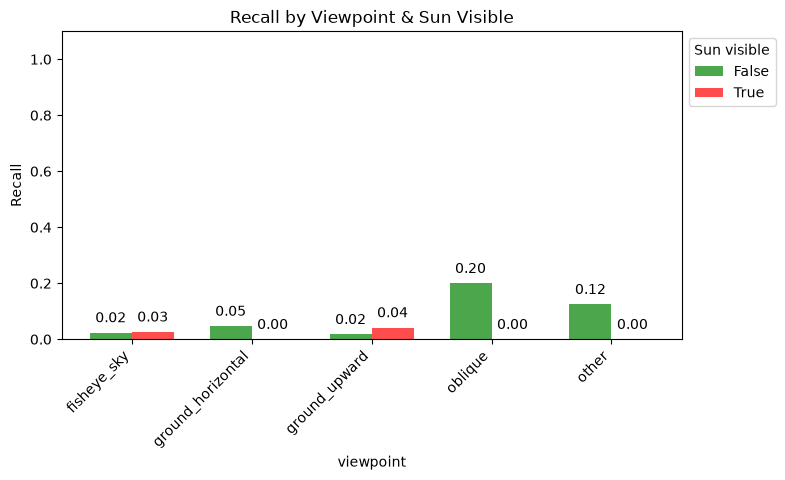

In [230]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='recall', 
    color_map=colors,
    ylabel="Recall", 
    xlabel=x_column, 
    title=f"Recall by {title}",
)


### Hit Rate

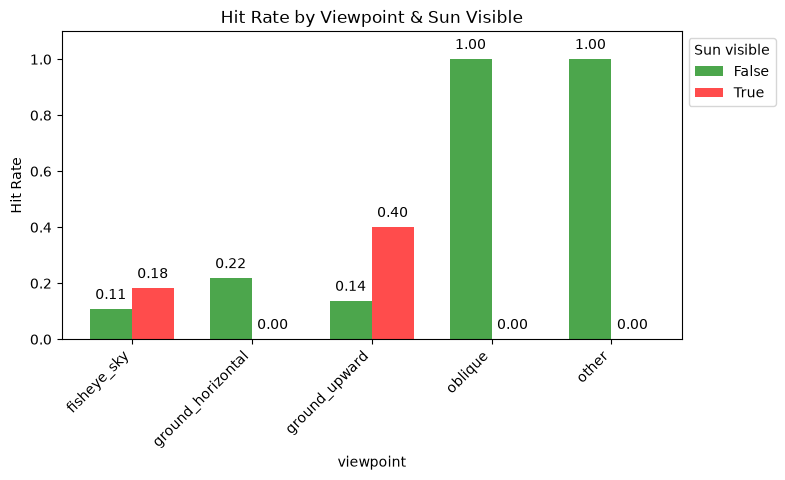

In [231]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='hit_rate', 
    color_map=colors,
    ylabel="Hit Rate", 
    xlabel=x_column, 
    title=f"Hit Rate by {title}",
)

### Diversity

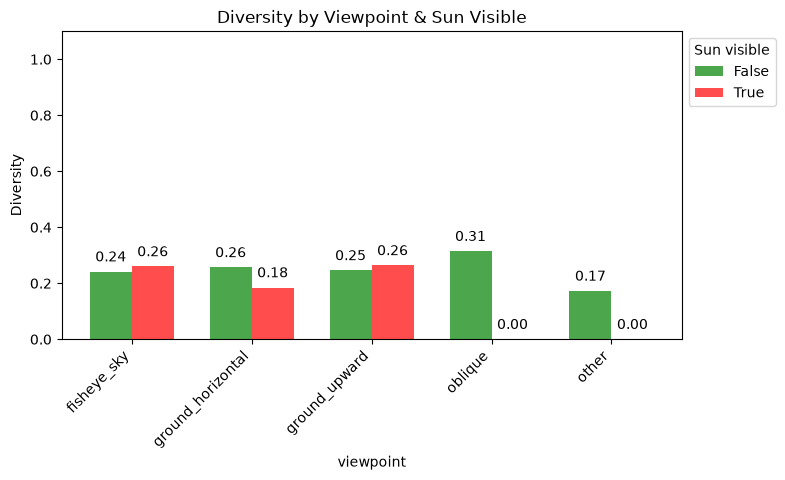

In [232]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='diversity', 
    color_map=colors,
    ylabel="Diversity", 
    xlabel=x_column, 
    title=f"Diversity by {title}",
)

### NDCG

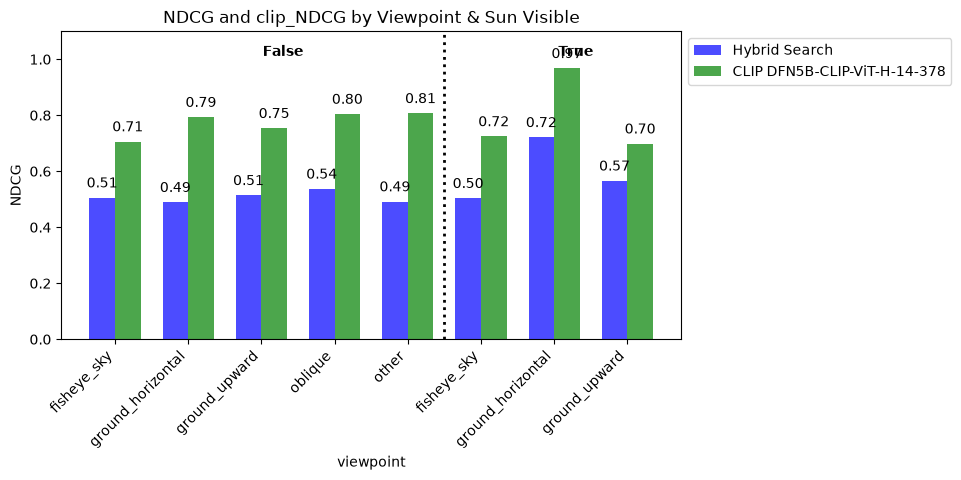

In [233]:
# Sort by group_column so group dividers and labels are correct
_ndcg_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column=x_column,
    group_column=group_column,
    title=f"NDCG and clip_NDCG by {title}",
    xlabel=x_column,
)


### MRR

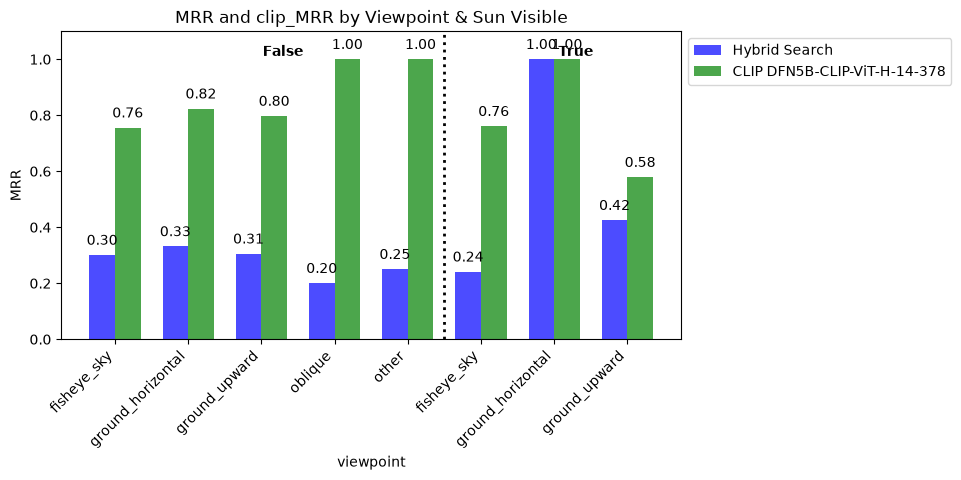

In [234]:
_mrr_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(_mrr_df, x_column=x_column, group_column=group_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Insights & Conclusion

**System Difference**

* **v12:** Weaviate hybrid search over **one fused CLIP index** (caption + image embeddings combined into a single `clip` vector), with the Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. CLIP inference had **no Triton dynamic batching**.
* **v13:**
  * **Weaviate → Milvus** as the vector database.
  * **Weaviate reranker → Apple CLIP DFN** (`DFN5B-CLIP-ViT-H-14-378`): query text vs stored `image_vector`s.
  * **One fused index → dual indexing**: separate `caption_vector` and `image_vector` fields, blended at query time (`clip_alpha=0.7`).
  * **No Triton batching → Triton dynamic batching** for CLIP (and Gemma when served on Triton), so concurrent embedding/caption requests coalesce into larger GPU batches.
* **v14:**
  * v13 additions plus LLM Image Byte Limiting - Caption images are preprocessed before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).

---

**Overall Metrics Comparison**

Byte limiting is the v14 increment on the v13 stack. **Δ (v13 − v12)** is the Milvus / dual-index / CLIP DFN move; **Δ (v14 − v13)** is caption image byte limiting; **Δ (v14 − v12)** is the net vs the Weaviate baseline.

| Metric                   | v12 | v13 | v14 | Δ (v13 − v12) | Δ (v14 − v13) | Δ (v14 − v12) |
| ------------------------ | --- | --- | --- | ------------- | ------------- | ------------- |
| **Total Images**         | 2,875 | 2,875 | 2,875 | 0 | 0 | 0 |
| **Correctly Returned**   | 39 | 36 | 33 | −3 | −3 | −6 |
| **Incorrectly Returned** | 2,836 | 2,839 | 2,842 | +3 | +3 | +6 |
| **Relevant Images**      | 36 | 32 | 22 | −4 | −10 | −14 |
| **Accuracy**             | 0.0136 | 0.0125 | 0.0115 | −0.0011 | −0.0010 | −0.0021 |
| **Precision**            | 0.0125 | 0.0111 | 0.0077 | −0.0014 | −0.0034 | −0.0048 |
| **Recall**               | 0.0645 | 0.0670 | 0.0353 | +0.0025 | −0.0317 | −0.0292 |
| **Hit Rate**             | 0.2696 | 0.2522 | 0.1913 | −0.0174 | −0.0609 | −0.0783 |
| **Diversity**            | 0.2027 | 0.2675 | 0.2506 | +0.0648 | −0.0169 | +0.0479 |
| **NDCG**                 | 0.5461 | 0.5203 | 0.5050 | −0.0258 | −0.0153 | −0.0411 |
| **clip_NDCG**            | 0.7585 | 0.7266 | 0.7552 | −0.0319 | +0.0286 | −0.0033 |
| **MRR**                  | 0.4193 | 0.3565 | 0.3182 | −0.0628 | −0.0383 | −0.1011 |
| **clip_MRR**             | 0.7701 | 0.7167 | 0.7897 | −0.0534 | +0.0730 | +0.0196 |
| **DLQ entries**          | — | 110 | 0 | — | −110 | — |

---

**Interpretation**

**Caption reliability is solved.** v13 had **110** DLQ rows (94 force-inserted with dataset-`summary` fallback, 16 recovered on retry, 0 abandoned; 76 unique images). v14 has **zero** DLQ rows: every image got a real Gemma caption under the 12 MiB / 6144-side cap.

**Labeled retrieval moved the other way — same sign as Firebench, opposite of Commonobjects.** Versus v13, v14 drops **relevant images** (−10), **hit rate** (−6.1 pp; 29/115 → 22/115), **recall** (−0.032), and **precision** (−0.0034). Versus v12, coverage is a clear net loss (hit rate **27.0% → 19.1%**). Byte limiting here is a **retrieval regression**, not a recovery.

**Production ranking keeps sliding; the CLIP oracle lists come back.** **NDCG** and **MRR** fall again vs v13 (MRR **0.36 → 0.32**, now −0.10 vs v12). **clip_NDCG / clip_MRR** snap back toward (and for MRR, above) v12 after v13's drop. The top‑25 sets are as CLIP-aligned as Weaviate again, but the **labels** in those lists are fewer, and the production CLIP DFN reranker still places the remaining hits later than MiniLM did.

**Diversity** gives back a little of the v13 gain (−0.017) but stays well above v12.

---

**Insights**

- **Same IR sign as Firebench v14, not Commonobjects.** Cloudbench is sky / all-sky webcam imagery. Downscaling long-side-capped frames costs Gemma the fine texture that queries name (cirrus veils, mackerel sky, thin contrails, distant towers). Ordinary object stills barely notice the cap; these skies do.
- **The retrieval drop is a caption-path story.** CLIP `image_vector`s and CLIP rerank never see the LLM-capped JPEG. Hybrid search still blends `caption_vector` and BM25 at `query_alpha=0.4`. Worse or more generic sky captions change who enters k=25.
- **v13 retrieval was partly inflated by `summary` fallback.** Those 94 force-inserts used dataset summaries — often cloud-type language that matches the queries. v14 is the first full-LLM-caption run on this stack; some of the −6.1 pp hit rate is “honest captions” vs “label-like summaries,” not only downscaling.
- **v13's fisheye / night / storm gains reversed.** Fisheye hit **0.21 → 0.13** (back to v12), night **0.19 → 0.12**, storm-visible **0.50 → 0.36** (below v12 0.43). Day **0.34 → 0.26** and ground-horizontal **0.32 → 0.21** keep falling. Mid coverage (50–75%) is the worst slice (**0.34 → 0.16**). Overcast lighting recovered some (**0.17 → 0.25**, still below v12 0.33).
- **Hit churn vs v13:** 11 queries gained a hit, 18 lost one. Losses concentrate on **towering convective** scenes, **cirrus/contrails**, and **nighttime fisheye wisps**. Gains are mostly **uniform stratus/overcast** plus a few altocumulus / artifact queries. Net coverage is down; it is not a uniform slide.
- **clip_NDCG recovering while labeled hit falls** means candidate generation became more CLIP-generic (sky-like frames rank well under the oracle) while **fine-grained labels** left the lists. Isolate byte limiting with **v14 vs v13**. Do not read v14 vs v12 as “byte limiting vs Weaviate.”

---

**Conclusion**

On Cloudbench, **v14 fixes caption DLQ (110 → 0) but labeled retrieval and production ranking are worse than both v13 and v12.** Hit rate **25.2% → 19.1%** (v12 27.0%); MRR **0.36 → 0.32** (v12 0.42). Byte limiting is still the right production default for NRP image size limits; the IR cost is concentrated on **caption quality for high-res all-sky / fine cloud texture**. Next steps match Firebench: **raise the resolution cap for captioning where NRP allows**, **keep CLIP on full-res images** (already true), and/or **tune `clip_alpha` / BM25** so a weaker caption leg cannot drop cirrus, contrails, and convective structure out of k=25. Do not roll back Milvus + CLIP DFN rerank on the basis of this run — Cloudbench already favored v12 Weaviate + MiniLM before byte limiting.

